# ЛАБОРАТОРНАЯ РАБОТА № 6

**Тема**: Предобработка данных, построение baseline-модели нейронной сети для задачи регрессии.

**Постановка**: Провести предобработку данных. Разработать класс модели нейронной сети, а также провести доаботку модели перебором гиперпараметров. Выявить лучшую из рассмотренных моделей.

**Цель**: Получить первичные навыки с работой нейронных моделей.

## Знакомство с данными

In [533]:
import warnings
warnings.filterwarnings('ignore')

### Установим красивые дефолтные настройки
### Может быть лень постоянно прописывать
### У графиков параметры цвета, размера, шрифта
### Можно положить их в словарь дефолтных настроек

import matplotlib as mlp

mlp.rcParams['lines.linewidth'] = 5
mlp.rcParams['xtick.major.size'] = 20
mlp.rcParams['xtick.major.width'] = 5
mlp.rcParams['xtick.labelsize'] = 20
mlp.rcParams['xtick.color'] = '#FF5533'

mlp.rcParams['ytick.major.size'] = 20
mlp.rcParams['ytick.major.width'] = 5
mlp.rcParams['ytick.labelsize'] = 20
mlp.rcParams['ytick.color'] = '#FF5533'

mlp.rcParams['axes.labelsize'] = 20
mlp.rcParams['axes.titlesize'] = 20
mlp.rcParams['axes.titlecolor'] = '#00B050'
mlp.rcParams['axes.labelcolor'] = '#00B050'

In [534]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [535]:
import pandas as pd

### Прочитаем табличку для 6 лабы
movies = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/6 лаба/mkrf_movies.csv')

movies.head(5)

,title,puNumber,show_start_date,type,film_studio,production_country,director,producer,age_restriction,refundable_support,nonrefundable_support,budget,financing_source,ratings,genres
0,Открытый простор,221048915,2015-11-27T12:00:00.000Z,Художественный,"Тачстоун Пикчерз, Кобальт Пикчерз, Бикон Пикче...",США,Кевин Костнер,"Дэвид Валдес, Кевин Костнер, Джейк Эбертс",«18+» - запрещено для детей,NaN,NaN,NaN,NaN,7.2,"боевик,драма,мелодрама"
1,Особо важное задание,111013716,2016-09-13T12:00:00.000Z,Художественный,"Киностудия ""Мосфильм""",СССР,Е.Матвеев,NaN,«6+» - для детей старше 6 лет,NaN,NaN,NaN,NaN,6.6,"драма,военный"
2,Особо опасен,221038416,2016-10-10T12:00:00.000Z,Художественный,"Юниверсал Пикчерз, Кикстарт Продакшнз, Марк Пл...",США,Тимур Бекмамбетов,"Джим Лемли, Джейсон Нетер, Марк Е.Платт, Яйн Смит",«18+» - запрещено для детей,NaN,NaN,NaN,NaN,6.8,"фантастика,боевик,триллер"
3,Особо опасен,221026916,2016-06-10T12:00:00.000Z,Художественный,"Юниверсал Пикчерз, Кикстарт Продакшнз, Марк Пл...",США,Тимур Бекмамбетов,"Джим Лемли, Джейсон Нетер, Марк Е.Платт, Яйн Смит",«18+» - запрещено для детей,NaN,NaN,NaN,NaN,6.8,"фантастика,боевик,триллер"
4,Особо опасен,221030815,2015-07-29T12:00:00.000Z,Художественный,"Юниверсал Пикчерз, Кикстарт Продакшнз, Марк Пл...",США,Тимур Бекмамбетов,"Джим Лемли, Джейсон Нетер, Марк Е.Платт, Яйн Смит",«18+» - запрещено для детей,NaN,NaN,NaN,NaN,6.8,"фантастика,боевик,триллер"


In [536]:
movies.dtypes

,0
title,object
puNumber,object
show_start_date,object
type,object
film_studio,object
production_country,object
director,object
producer,object
age_restriction,object
refundable_support,float64


In [537]:
### Проверка на дубликаты
movies.duplicated().sum()

np.int64(0)

In [538]:
print(f'Всего колонок: {movies.shape[1]}')
print(f'Всего данных (строк): {len(movies)}')

Всего колонок: 15
Всего данных (строк): 7486


In [539]:
print(movies['ratings'].unique())

['7.2' '6.6' '6.8' '7.7' '8.3' '8.0' '7.8' '8.1' '7.1' '6.0' '7.4' '5.8'
 '8.7' '6.3' '6.9' '5.0' '4.3' '7.3' '7.0' '6.4' nan '8.2' '7.5' '6.7'
 '7.9' '5.9' '6.2' '5.6' '6.5' '2.4' '7.6' '6.1' '8.6' '8.5' '8.8' '5.5'
 '5.1' '5.7' '5.4' '99%' '4.4' '4.5' '5.3' '4.1' '8.4' '2.6' '3.8' '4.6'
 '4.8' '4.0' '3.0' '1.6' '4.2' '5.2' '4.7' '4.9' '3.9' '2.7' '3.3' '2.9'
 '28%' '3.7' '1.4' '3.1' '97%' '3.5' '3.2' '2.8' '1.5' '2.1' '2.5' '9.2'
 '3.4' '1.1' '3.6' '83%' '64%' '91%' '94%' '62%' '79%' '90%' '19%' '88%'
 '1.0' '89%' '1.3' '1.9' '1.8' '1.2' '1.7' '9.0' '98%' '8.9' '9.1']


In [540]:
movies['ratings'].isna().sum()

np.int64(967)

Не понимаю, таргет очень странный, тут есть адкватные оценки, есть пропуски, есть какие-то процентные значения, каким образом предсказывать это будем, в классификацию не переделать, слишком много разных уникальныъ значений, 8-ая часть фильмов вообще без рэйтинга, я не вижу смысла на них обучать данные, уберу их в мешок какой-нибудь

In [541]:
nan_rating_films = movies[movies['ratings'].isna()]
nan_rating_films.head()

,title,puNumber,show_start_date,type,film_studio,production_country,director,producer,age_restriction,refundable_support,nonrefundable_support,budget,financing_source,ratings,genres
43,Мемуары гейши (по роману Артура Голдена),121000606,2012-12-14T12:00:00.000Z,Художественный,"Коламбия Пикчерз Корпорейшн, ДримУоркс ЭсКейДж...",США,Роб Маршалл,"Стивен Спилберг, Люси Фишер, Дуглас Уик, Джон ...",«12+» - для детей старше 12 лет,NaN,NaN,NaN,NaN,NaN,NaN
150,Жди меня,111013615,2015-08-25T12:00:00.000Z,Художественный,"Киностудия ""Мосфильм""",СССР,"А.Столпер, Б.Иванов",NaN,«6+» - для детей старше 6 лет,NaN,NaN,NaN,NaN,NaN,NaN
154,Дом из песка и тумана (по книге Андре Дюбуи III),221037813,2013-10-25T12:00:00.000Z,Художественный,Кобальт Пикчерз,США,Вадим Перельман,Майкл Лондон,«16+» - для детей старше 16 лет,NaN,NaN,NaN,NaN,NaN,NaN
159,Жемчужная девушка,224011014,2014-08-28T12:00:00.000Z,Художественный,"Чешское телевидение,Студия ""Три брата"" агентск...",Чехия,Владимир Дрга,NaN,«0+» - для любой зрительской аудитории,NaN,NaN,NaN,NaN,NaN,NaN
227,Полустанок,111026714,2014-12-24T12:00:00.000Z,Художественный,"Киностудия ""Мосфильм""",СССР,Б.Барнет,NaN,«12+» - для детей старше 12 лет,NaN,NaN,NaN,NaN,NaN,NaN


In [542]:
movies = movies[movies['ratings'].notna()]
movies.head()

,title,puNumber,show_start_date,type,film_studio,production_country,director,producer,age_restriction,refundable_support,nonrefundable_support,budget,financing_source,ratings,genres
0,Открытый простор,221048915,2015-11-27T12:00:00.000Z,Художественный,"Тачстоун Пикчерз, Кобальт Пикчерз, Бикон Пикче...",США,Кевин Костнер,"Дэвид Валдес, Кевин Костнер, Джейк Эбертс",«18+» - запрещено для детей,NaN,NaN,NaN,NaN,7.2,"боевик,драма,мелодрама"
1,Особо важное задание,111013716,2016-09-13T12:00:00.000Z,Художественный,"Киностудия ""Мосфильм""",СССР,Е.Матвеев,NaN,«6+» - для детей старше 6 лет,NaN,NaN,NaN,NaN,6.6,"драма,военный"
2,Особо опасен,221038416,2016-10-10T12:00:00.000Z,Художественный,"Юниверсал Пикчерз, Кикстарт Продакшнз, Марк Пл...",США,Тимур Бекмамбетов,"Джим Лемли, Джейсон Нетер, Марк Е.Платт, Яйн Смит",«18+» - запрещено для детей,NaN,NaN,NaN,NaN,6.8,"фантастика,боевик,триллер"
3,Особо опасен,221026916,2016-06-10T12:00:00.000Z,Художественный,"Юниверсал Пикчерз, Кикстарт Продакшнз, Марк Пл...",США,Тимур Бекмамбетов,"Джим Лемли, Джейсон Нетер, Марк Е.Платт, Яйн Смит",«18+» - запрещено для детей,NaN,NaN,NaN,NaN,6.8,"фантастика,боевик,триллер"
4,Особо опасен,221030815,2015-07-29T12:00:00.000Z,Художественный,"Юниверсал Пикчерз, Кикстарт Продакшнз, Марк Пл...",США,Тимур Бекмамбетов,"Джим Лемли, Джейсон Нетер, Марк Е.Платт, Яйн Смит",«18+» - запрещено для детей,NaN,NaN,NaN,NaN,6.8,"фантастика,боевик,триллер"


In [543]:
print(movies['ratings'].unique())

['7.2' '6.6' '6.8' '7.7' '8.3' '8.0' '7.8' '8.1' '7.1' '6.0' '7.4' '5.8'
 '8.7' '6.3' '6.9' '5.0' '4.3' '7.3' '7.0' '6.4' '8.2' '7.5' '6.7' '7.9'
 '5.9' '6.2' '5.6' '6.5' '2.4' '7.6' '6.1' '8.6' '8.5' '8.8' '5.5' '5.1'
 '5.7' '5.4' '99%' '4.4' '4.5' '5.3' '4.1' '8.4' '2.6' '3.8' '4.6' '4.8'
 '4.0' '3.0' '1.6' '4.2' '5.2' '4.7' '4.9' '3.9' '2.7' '3.3' '2.9' '28%'
 '3.7' '1.4' '3.1' '97%' '3.5' '3.2' '2.8' '1.5' '2.1' '2.5' '9.2' '3.4'
 '1.1' '3.6' '83%' '64%' '91%' '94%' '62%' '79%' '90%' '19%' '88%' '1.0'
 '89%' '1.3' '1.9' '1.8' '1.2' '1.7' '9.0' '98%' '8.9' '9.1']


In [544]:
print(len(movies[movies['ratings'].str.contains('%')]))
movies[movies['ratings'].str.contains('%')]

29


,title,puNumber,show_start_date,type,film_studio,production_country,director,producer,age_restriction,refundable_support,nonrefundable_support,budget,financing_source,ratings,genres
259,Прошлое,221030715,2015-07-29T12:00:00.000Z,Художественный,"20 Сенчюри Фокс де Архентина, Чемо, ЭйчБи Филм...",Аргентина - Бразилия,Эктор Бабенко,"Эктор Бабенко, Оскар Крамер, Хуго Сидмэн",«16+» - для детей старше 16 лет,NaN,NaN,NaN,NaN,99%,"ужасы,триллер,драма"
811,От винта!,114000212,2012-08-06T12:00:00.000Z,Анимационный,"ЗАО ""Продюсерский центр ""Парадиз""",Россия,О.Лопато,"Г.Нерсисян, А.Манасарян, А.Нерсесян",«12+» - для детей старше 12 лет,NaN,NaN,NaN,NaN,28%,"детский,приключения,комедия"
1053,Песочный человек,121029212,2012-11-29T12:00:00.000Z,Художественный,Спотлайт Медиа Продакшн,Швейцария,Питер Луизи,"Дэвид Луизи, Питер Луизи",«16+» - для детей старше 16 лет,NaN,NaN,NaN,NaN,97%,"ужасы,фантастика,фэнтези"
1341,Сказка о добре и Вре,111008913,2013-11-15T12:00:00.000Z,Художественный,"НП ""Студия игрового кино ""Лик""",Россия,Е.Шиляева,К.Терещенко,«6+» - для детей старше 6 лет,NaN,NaN,NaN,NaN,99%,"триллер,драма,детектив"
1805,Спираль.,111001014,2014-01-30T12:00:00.000Z,Художественный,"ООО ""Компания Питон""",Россия,А.Волгин,Е.Ковалева,«12+» - для детей старше 12 лет,NaN,NaN,NaN,NaN,99%,"аниме,мультфильм,ужасы"
1874,Короткие истории о любви 2,121002615,2015-02-13T12:00:00.000Z,Художественный,"Кавиар, Курт 13, СтритЛайт Филмз, Нэйер Дойче ...",Нидерланды - США - Германия - Канада - Франция...,"Мэтью Аувро, Лео Брайдл, Бен Бренд, Ден Кларк,...","Мэри Пэт Бентел, Бен Бренд, Сиара Гиллан, Джор...",«18+» - запрещено для детей,NaN,NaN,NaN,NaN,83%,NaN
1899,Золушка /По сказке Шарля Перро/. Холодное торж...,121003615,2015-02-27T12:00:00.000Z,Художественный,"Женр Филмз, Уолт Дисней Пикчерз",США,Кеннет Брана,"Дэвид Бэррон, Саймон Кинберг, Эллисон Ширмур",«6+» - для детей старше 6 лет,NaN,NaN,NaN,NaN,64%,"мюзикл,фэнтези,мелодрама"
2126,Поездка к матери,111002015,2015-03-02T12:00:00.000Z,Художественный,"ЗАО ""Киностудия ""М""-Фильм""",Россия,М.Косырев-Нестеров,М.Косырев-Нестеров,«16+» - для детей старше 16 лет,NaN,NaN,NaN,NaN,91%,"драма,семейный"
2146,Главный,111003415,2015-03-27T12:00:00.000Z,Художественный,"ООО ""Киностудия ""МАСТЕР""",Россия,Ю.Кара,Ю.Кара,«6+» - для детей старше 6 лет,0.0,10000000.0,40000000.0,Министерство культуры,94%,"фантастика,боевик,комедия"
2438,Самый рыжий Лис,111012715,2015-07-30T12:00:00.000Z,Художественный,"ООО ""Продюсерский центр ""Ленфильм""",Россия,А.Стреляная,"А.Котелевский, Э.Пичугин",«6+» - для детей старше 6 лет,NaN,NaN,NaN,NaN,62%,"фэнтези,семейный"


Честно, я бы через API добавил реальные значения рэйтингов для каждого фильма, но мне для этого токен нужен кп, но он платный, не хочу)

А так я посмотрел, что у условного фильма поездка к матери рэйтинг 6.2 на кинопоиске, а здесь какой-то 91%.

Всего таких фильмов 29, я удалю, чтобы не мешали

In [545]:
movies = movies[~movies['ratings'].str.contains('%')]
print(movies['ratings'].unique())
movies.head(5)

['7.2' '6.6' '6.8' '7.7' '8.3' '8.0' '7.8' '8.1' '7.1' '6.0' '7.4' '5.8'
 '8.7' '6.3' '6.9' '5.0' '4.3' '7.3' '7.0' '6.4' '8.2' '7.5' '6.7' '7.9'
 '5.9' '6.2' '5.6' '6.5' '2.4' '7.6' '6.1' '8.6' '8.5' '8.8' '5.5' '5.1'
 '5.7' '5.4' '4.4' '4.5' '5.3' '4.1' '8.4' '2.6' '3.8' '4.6' '4.8' '4.0'
 '3.0' '1.6' '4.2' '5.2' '4.7' '4.9' '3.9' '2.7' '3.3' '2.9' '3.7' '1.4'
 '3.1' '3.5' '3.2' '2.8' '1.5' '2.1' '2.5' '9.2' '3.4' '1.1' '3.6' '1.0'
 '1.3' '1.9' '1.8' '1.2' '1.7' '9.0' '8.9' '9.1']


,title,puNumber,show_start_date,type,film_studio,production_country,director,producer,age_restriction,refundable_support,nonrefundable_support,budget,financing_source,ratings,genres
0,Открытый простор,221048915,2015-11-27T12:00:00.000Z,Художественный,"Тачстоун Пикчерз, Кобальт Пикчерз, Бикон Пикче...",США,Кевин Костнер,"Дэвид Валдес, Кевин Костнер, Джейк Эбертс",«18+» - запрещено для детей,NaN,NaN,NaN,NaN,7.2,"боевик,драма,мелодрама"
1,Особо важное задание,111013716,2016-09-13T12:00:00.000Z,Художественный,"Киностудия ""Мосфильм""",СССР,Е.Матвеев,NaN,«6+» - для детей старше 6 лет,NaN,NaN,NaN,NaN,6.6,"драма,военный"
2,Особо опасен,221038416,2016-10-10T12:00:00.000Z,Художественный,"Юниверсал Пикчерз, Кикстарт Продакшнз, Марк Пл...",США,Тимур Бекмамбетов,"Джим Лемли, Джейсон Нетер, Марк Е.Платт, Яйн Смит",«18+» - запрещено для детей,NaN,NaN,NaN,NaN,6.8,"фантастика,боевик,триллер"
3,Особо опасен,221026916,2016-06-10T12:00:00.000Z,Художественный,"Юниверсал Пикчерз, Кикстарт Продакшнз, Марк Пл...",США,Тимур Бекмамбетов,"Джим Лемли, Джейсон Нетер, Марк Е.Платт, Яйн Смит",«18+» - запрещено для детей,NaN,NaN,NaN,NaN,6.8,"фантастика,боевик,триллер"
4,Особо опасен,221030815,2015-07-29T12:00:00.000Z,Художественный,"Юниверсал Пикчерз, Кикстарт Продакшнз, Марк Пл...",США,Тимур Бекмамбетов,"Джим Лемли, Джейсон Нетер, Марк Е.Платт, Яйн Смит",«18+» - запрещено для детей,NaN,NaN,NaN,NaN,6.8,"фантастика,боевик,триллер"


In [546]:
print(f'Всего колонок: {movies.shape[1]}')
print(f'Всего данных (строк): {len(movies)}')

Всего колонок: 15
Всего данных (строк): 6490


Избавились от чуть больше тысячи фильмов, не подлежащих данной задаче, я выбираю регрессионый подход

In [547]:
### переведем колонку рэйтингов во флоат формат
movies['ratings'] = movies['ratings'].astype(float)

In [548]:
movies['puNumber'] = movies['puNumber'].astype(int)

In [549]:
movies['ratings']

,ratings
0,7.2
1,6.6
2,6.8
3,6.8
4,6.8
...,...
7476,5.9
7477,6.3
7478,4.5
7482,5.4


In [550]:
movies.describe()

,puNumber,refundable_support,nonrefundable_support,budget,ratings
count,6.490000e+03,3.140000e+02,3.140000e+02,3.140000e+02,6490.000000
mean,1.372347e+08,1.232166e+07,4.977076e+07,1.313466e+08,6.479245
std,3.988400e+07,2.546111e+07,6.122000e+07,1.929207e+08,1.101665
min,1.811096e+06,0.000000e+00,0.000000e+00,0.000000e+00,1.000000
25%,1.140033e+08,0.000000e+00,2.500000e+07,4.289500e+07,5.900000
50%,1.210167e+08,0.000000e+00,3.000000e+07,7.059059e+07,6.600000
75%,1.240026e+08,1.500000e+07,4.412500e+07,1.500064e+08,7.200000
max,2.310011e+08,1.800000e+08,4.000000e+08,2.305074e+09,9.200000


In [551]:
movies.describe(include='object')

,title,show_start_date,type,film_studio,production_country,director,producer,age_restriction,financing_source,genres
count,6490,6490,6490,6485,6488,6487,6012,6490,314,6484
unique,5785,1803,8,4934,874,4134,4769,5,3,739
top,День святого Валентина_,2010-12-17T12:00:00.000Z,Художественный,"Киностудия ""Мосфильм""",США,Стивен Содерберг,С.Сельянов,«16+» - для детей старше 16 лет,Министерство культуры,драма
freq,5,95,4290,331,2101,17,18,2655,151,472


In [552]:
### Прочитаем табличку для 6 лабы
shows = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/6 лаба/mkrf_shows.csv')

shows.head(5)

,puNumber,box_office
0,111000113,2.450000e+03
1,111000115,6.104000e+04
2,111000116,1.530300e+08
3,111000117,1.226096e+07
4,111000118,1.636841e+08


In [553]:
shows.dtypes

,0
puNumber,int64
box_office,float64


In [554]:
### Проверка на дубликаты
shows.duplicated().sum()

np.int64(0)

In [555]:
print(f'Всего колонок: {shows.shape[1]}')
print(f'Всего данных (строк): {len(shows)}')

Всего колонок: 2
Всего данных (строк): 3158


не знаю, что пока делать с табличкой сборов, тая как будто у половины данных будет пропуски

In [556]:
films_by_title = movies.groupby('title').agg({
    'puNumber': 'count',
    'ratings': 'mean'
}).reset_index()

print(films_by_title[films_by_title['puNumber'] > 1].sort_values('puNumber', ascending=False))

                                                  title  puNumber  ratings
1300                            День святого Валентина_         5      6.7
1247                                      Двойной копец         4      6.0
5608                                       Шерлок Холмс         4      8.1
4987                            Там, где живут чудовища         4      6.9
5369                                             Химера         4      5.7
...                                                 ...       ...      ...
5488                    Чего ждать, когда ждешь ребенка         2      6.6
5478                                    Час призраков 2         2      4.1
5477                                      Час призраков         2      4.9
5459                                          Центурион         2      6.6
5431  Хроники Нарнии: Покоритель Зари /По произведен...         2      6.9

[549 rows x 3 columns]


In [557]:
movies[movies['title']=='Этим утром в Нью-Йорке']

,title,puNumber,show_start_date,type,film_studio,production_country,director,producer,age_restriction,refundable_support,nonrefundable_support,budget,financing_source,ratings,genres
1811,Этим утром в Нью-Йорке,221033214,2014-08-20T12:00:00.000Z,Художественный,"Лэндскейп Интертейнмент, Форс Мажор, Проминент...",США,Фил Олден Робинсон,"Боб Купер, Тайлер Митчелл, Дэниэл Дж. Уолкер",«12+» - для детей старше 12 лет,NaN,NaN,NaN,NaN,6.2,"драма,комедия"
1812,Этим утром в Нью-Йорке,121009614,2014-05-21T12:00:00.000Z,Художественный,"Лэндскейп Интертейнмент, Форс Мажор, Проминент...",США,Фил Олден Робинсон,"Боб Купер, Тайлер Митчелл, Дэниэл Дж. Уолкер",«12+» - для детей старше 12 лет,NaN,NaN,NaN,NaN,6.2,"драма,комедия"


In [558]:
combined_df = pd.merge(movies, shows, on='puNumber', how='left')
combined_df.head(5)

,title,puNumber,show_start_date,type,film_studio,production_country,director,producer,age_restriction,refundable_support,nonrefundable_support,budget,financing_source,ratings,genres,box_office
0,Открытый простор,221048915,2015-11-27T12:00:00.000Z,Художественный,"Тачстоун Пикчерз, Кобальт Пикчерз, Бикон Пикче...",США,Кевин Костнер,"Дэвид Валдес, Кевин Костнер, Джейк Эбертс",«18+» - запрещено для детей,NaN,NaN,NaN,NaN,7.2,"боевик,драма,мелодрама",NaN
1,Особо важное задание,111013716,2016-09-13T12:00:00.000Z,Художественный,"Киностудия ""Мосфильм""",СССР,Е.Матвеев,NaN,«6+» - для детей старше 6 лет,NaN,NaN,NaN,NaN,6.6,"драма,военный",NaN
2,Особо опасен,221038416,2016-10-10T12:00:00.000Z,Художественный,"Юниверсал Пикчерз, Кикстарт Продакшнз, Марк Пл...",США,Тимур Бекмамбетов,"Джим Лемли, Джейсон Нетер, Марк Е.Платт, Яйн Смит",«18+» - запрещено для детей,NaN,NaN,NaN,NaN,6.8,"фантастика,боевик,триллер",NaN
3,Особо опасен,221026916,2016-06-10T12:00:00.000Z,Художественный,"Юниверсал Пикчерз, Кикстарт Продакшнз, Марк Пл...",США,Тимур Бекмамбетов,"Джим Лемли, Джейсон Нетер, Марк Е.Платт, Яйн Смит",«18+» - запрещено для детей,NaN,NaN,NaN,NaN,6.8,"фантастика,боевик,триллер",NaN
4,Особо опасен,221030815,2015-07-29T12:00:00.000Z,Художественный,"Юниверсал Пикчерз, Кикстарт Продакшнз, Марк Пл...",США,Тимур Бекмамбетов,"Джим Лемли, Джейсон Нетер, Марк Е.Платт, Яйн Смит",«18+» - запрещено для детей,NaN,NaN,NaN,NaN,6.8,"фантастика,боевик,триллер",NaN


In [559]:
combined_df[combined_df['title']=='Этим утром в Нью-Йорке']

,title,puNumber,show_start_date,type,film_studio,production_country,director,producer,age_restriction,refundable_support,nonrefundable_support,budget,financing_source,ratings,genres,box_office
1685,Этим утром в Нью-Йорке,221033214,2014-08-20T12:00:00.000Z,Художественный,"Лэндскейп Интертейнмент, Форс Мажор, Проминент...",США,Фил Олден Робинсон,"Боб Купер, Тайлер Митчелл, Дэниэл Дж. Уолкер",«12+» - для детей старше 12 лет,NaN,NaN,NaN,NaN,6.2,"драма,комедия",1090.0
1686,Этим утром в Нью-Йорке,121009614,2014-05-21T12:00:00.000Z,Художественный,"Лэндскейп Интертейнмент, Форс Мажор, Проминент...",США,Фил Олден Робинсон,"Боб Купер, Тайлер Митчелл, Дэниэл Дж. Уолкер",«12+» - для детей старше 12 лет,NaN,NaN,NaN,NaN,6.2,"драма,комедия",360.0


Я буду объединять сборы одинаковых фильмов

In [560]:
# Если знаете точные названия колонок
imdb = combined_df.groupby('title').agg({
    'show_start_date': 'first',
    'type': 'first',
    'film_studio': 'first',
    'production_country': 'first',
    'director': 'first',
    'producer': 'first',
    'age_restriction': 'first',
    'refundable_support': 'first',
    'nonrefundable_support': 'first',
    'budget': 'first',
    'financing_source': 'first',
    'ratings': 'first',
    'genres': 'first',
    'box_office': 'sum'
}).reset_index()

In [561]:
imdb[imdb['title']=='Этим утром в Нью-Йорке']

,title,show_start_date,type,film_studio,production_country,director,producer,age_restriction,refundable_support,nonrefundable_support,budget,financing_source,ratings,genres,box_office
5713,Этим утром в Нью-Йорке,2014-08-20T12:00:00.000Z,Художественный,"Лэндскейп Интертейнмент, Форс Мажор, Проминент...",США,Фил Олден Робинсон,"Боб Купер, Тайлер Митчелл, Дэниэл Дж. Уолкер",«12+» - для детей старше 12 лет,NaN,NaN,NaN,None,6.2,"драма,комедия",1450.0


## Обработка пропусков

In [562]:
### проверим количество пропусков в каждой из колонок, а также число их уникальных значений
missing_values = imdb.isna().sum()
if missing_values.sum() > 0:
    print('Есть пропуски:')
    columns_with_missing = missing_values[missing_values > 0]
    print(columns_with_missing)

    print('\nКоличество уникальных значений для колонок с пропусками:')
    for col in columns_with_missing.index:
        unique_count = imdb[col].nunique()
        print(f'{col}: {unique_count} уникальных значений')

    print('\nНет пропусков у колонок:')
    columns_without_missing = missing_values[missing_values == 0].index.tolist()
    print(columns_without_missing)
else:
    print('Пропусков нет')

print(f'\nВсего строк: {imdb.shape[0]}')

Есть пропуски:
film_studio                 5
production_country          2
director                    3
producer                  464
refundable_support       5471
nonrefundable_support    5471
budget                   5471
financing_source         5471
genres                      6
dtype: int64

Количество уникальных значений для колонок с пропусками:
film_studio: 4890 уникальных значений
production_country: 867 уникальных значений
director: 4110 уникальных значений
producer: 4732 уникальных значений
refundable_support: 34 уникальных значений
nonrefundable_support: 73 уникальных значений
budget: 277 уникальных значений
financing_source: 3 уникальных значений
genres: 739 уникальных значений

Нет пропусков у колонок:
['title', 'show_start_date', 'type', 'age_restriction', 'ratings', 'box_office']

Всего строк: 5785


In [563]:
print(len(movies['film_studio'].unique()))
print(movies['film_studio'].unique())

4935
['Тачстоун Пикчерз, Кобальт Пикчерз, Бикон Пикчерз, Тиг Продакшнз'
 'Киностудия "Мосфильм"'
 'Юниверсал Пикчерз, Кикстарт Продакшнз, Марк Платт Продакшнз, Рилейтивити Медиа, Спайгласс Интертейнмент, Стилкин Филмз, Топ Кау Продакшнз'
 ... 'Демнехст ауф видео'
 'Дэниел Гродник Продакшнз, Вандерфилм Медиа Корпорэйшн, Импринт Интертейнмент, Вор Хорс Интертейнмент, Пимиента '
 'Анимаккорд Лтд., ООО Студия "АНИМАККОРД"']


In [564]:
imdb[imdb['film_studio'].isna()]

,title,show_start_date,type,film_studio,production_country,director,producer,age_restriction,refundable_support,nonrefundable_support,budget,financing_source,ratings,genres,box_office
145,Stars in Shorts,2014-06-03T12:00:00.000Z,Художественный,None,"США, Великобритания","Роберт Фестингер, Руперт Френд, Джей Камен, Ни...","Татьяна Келли, Роберта Мунро, Руперт Френд, До...",«16+» - для детей старше 16 лет,NaN,NaN,NaN,None,7.3,комедия,0.0
662,В плену города грёз,2018-12-06T12:00:00.000Z,Документальный,None,Россия,В.Витовцев,О.Мичи,«18+» - запрещено для детей,NaN,NaN,NaN,None,7.9,"фантастика,боевик,триллер",0.0
1426,До и После,2018-12-05T12:00:00.000Z,Документальный,None,Россия,А.Новокреповская,А.Новокреповская,«6+» - для детей старше 6 лет,NaN,NaN,NaN,None,6.9,"драма,криминал,детектив",0.0
3013,Мульт личности. Выпуск 5,2010-01-25T12:00:00.000Z,Художественный,None,None,None,None,«0+» - для любой зрительской аудитории,NaN,NaN,NaN,None,4.0,"мультфильм,комедия",0.0
5084,Топливо,2019-02-12T12:00:00.000Z,Художественный,None,Россия,М.Архипов,М.Архипов,«12+» - для детей старше 12 лет,NaN,NaN,NaN,None,6.1,"короткометражка,фантастика",0.0


Студии данных фильмов неизвестны, кстати, в детстве припоминаю мульт личности, это вроде пародия на звезд в мультиках, заполнять пропуски какой-то студией не имеет смысла, пусть будут с none, ничего страшного

In [565]:
imdb[imdb['production_country'].isna()]

,title,show_start_date,type,film_studio,production_country,director,producer,age_restriction,refundable_support,nonrefundable_support,budget,financing_source,ratings,genres,box_office
1335,"Детский юмористический киножурнал ""Ералаш. Ну ...",2016-02-09T12:00:00.000Z,Художественный,"ООО ""Продюсерский центр ЕРАЛАШ""",None,"Р.Светлов, И.Магитон, А.Арутюнян, Л.Мирский, А...","ООО ""Продюсерский центр ЕРАЛАШ""",«0+» - для любой зрительской аудитории,NaN,NaN,NaN,None,7.2,"детский,комедия",194527.0
3013,Мульт личности. Выпуск 5,2010-01-25T12:00:00.000Z,Художественный,None,None,None,None,«0+» - для любой зрительской аудитории,NaN,NaN,NaN,None,4.0,"мультфильм,комедия",0.0


тут явно страна Россия в пропусках:

In [566]:
print(imdb['production_country'].unique())

['Индия' 'СССР' 'США - Германия - Великобритания' 'Республика Кипр-Россия'
 'Россия' 'США' 'Республика Кипр, США, Россия' 'Франция'
 'США - Великобритания' 'Аргентина' 'Испания - США' 'Австралия' 'Германия'
 'Франция-Грузия-Германия-Россия-Украина-Бельгия' 'Польша - Ирландия'
 'США - Испания' 'США-Великобритания' 'Великобритания - Франция - США'
 'Япония-Великобритания' 'Франция-Канада' 'Великобритания'
 'Германия - Швейцария' 'США - ЮАР - Гонконг'
 'Германия - Австрия - Франция' 'Франция - Германия - Бельгия'
 'Республика Корея' 'Россия - Германия - Украина' 'Италия'
 'США - Швейцария - Франция' 'Великобритания, Новая Зеландия'
 'Великобритания-США' 'Испания' 'Парагвай' 'Казахстан' 'США - Финляндия'
 'Южная Корея' 'Япония' 'США, Франция' 'Канада - США'
 'США - Финляндия - Испания - Великобритания - Франция'
 'США - Канада - Афганистан - Бельгия - Франция'
 'Испания, Франция, Великобритания, Дания, Бельгия, Германия'
 'Румыния, ЮАР, Иран, Франция, Канада, Великобритания'
 'Франция - Ве

In [567]:
imdb[imdb['production_country']=='Россия']

,title,show_start_date,type,film_studio,production_country,director,producer,age_restriction,refundable_support,nonrefundable_support,budget,financing_source,ratings,genres,box_office
4,"""Море""",2013-03-13T12:00:00.000Z,Художественный,"ООО ""ТПО ""РОК"", ООО ""Коломна""",Россия,А.Стреляная,А.Учитель,«16+» - для детей старше 16 лет,NaN,NaN,NaN,None,6.1,"триллер,драма,детектив",0.0
7,"""Хороший день"", ""Бог из машины/Deus EX"", ""Голо...",2018-10-08T12:00:00.000Z,Художественный,"ООО ""Кинокомпания Белый Зонт"", ООО ""Базелевс п...",Россия,"Д.Кузнецов (псевдоним - Хаски), Д.Найшуллер (п...","ООО ""Яндекс. Такси""",«16+» - для детей старше 16 лет,NaN,NaN,NaN,None,7.8,"драма,комедия",0.0
9,(Не)идеальный мужчина,2019-12-24T12:00:00.000Z,Художественный,"ООО ""Нон-Стоп Продакшн""",Россия,М.Бальчюнас (псевдоним М.Вайсберг),"С.Мелькумов, А.Роднянский, М.Вайсберг, Р.Минас...",«12+» - для детей старше 12 лет,40000000.0,60000000.0,150147502.0,Фонд кино,4.5,"комедия,фантастика,мелодрама",0.0
10,... в стиле JAZZ,2011-03-10T12:00:00.000Z,Художественный,"ООО ""Киностудия ""Вертикаль""",Россия,С.Говорухин,"С.Говорухин, А.Просянов",«16+» - для детей старше 16 лет,NaN,NaN,NaN,None,6.1,"мелодрама,комедия",5620.0
11,... и я там был,2013-12-13T12:00:00.000Z,Художественный,"ООО ""Продюсерская кинокомпания ""Киностудия ""Луч""",Россия,"А.Зеленков, Л.Биц, А.Муратов","К.Мелик-Авакян, Л.Биц",«6+» - для детей старше 6 лет,NaN,NaN,NaN,None,7.7,"драма,комедия",73180.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5774,"Я, мама и Борис Пастернак",2018-09-17T12:00:00.000Z,Документальный,"ООО ""Пигмалион Пикчерс""",Россия,И.Семашко,О.Могучев,«12+» - для детей старше 12 лет,NaN,NaN,NaN,None,7.7,"триллер,драма,комедия",0.0
5776,Я-Учитель,2015-12-02T12:00:00.000Z,Художественный,"НП Киностудия детских и юношеских фильмов ""Иль...",Россия,С.Мокрицкий,А.Ковтунец,«12+» - для детей старше 12 лет,0.0,35000000.0,91000000.0,Министерство культуры,7.4,"мелодрама,комедия",1550.0
5778,Явление природы,2010-12-08T12:00:00.000Z,Художественный,"ООО ""Адрес Фильм""",Россия,"С.Осипьян, А.Лунгин","В.Кречетова, А.Васильев",«16+» - для детей старше 16 лет,NaN,NaN,NaN,None,5.7,драма,0.0
5781,Яна + Янко,2017-01-20T12:00:00.000Z,Художественный,"ООО ""Магнум-фильм""",Россия,Н.Меркулова,А.Семенов,«12+» - для детей старше 12 лет,15000000.0,28500000.0,68809226.0,Фонд кино,6.2,"комедия,семейный",1802175.0


In [568]:
imdb['production_country'] = imdb['production_country'].fillna('Россия')
if imdb['production_country'].isna().sum() == 0:
  print('пропусков не осталось')

пропусков не осталось


In [569]:
imdb[imdb['director'].isna()]

,title,show_start_date,type,film_studio,production_country,director,producer,age_restriction,refundable_support,nonrefundable_support,budget,financing_source,ratings,genres,box_office
104,Bon Jovi. The Circle Tour,2010-11-11T12:00:00.000Z,Прочие,Эншутц Интертейнмент Груп,США,None,Эншутц Интертейнмент Груп,«0+» - для любой зрительской аудитории,NaN,NaN,NaN,None,7.9,"концерт,музыка",0.0
3013,Мульт личности. Выпуск 5,2010-01-25T12:00:00.000Z,Художественный,None,Россия,None,None,«0+» - для любой зрительской аудитории,NaN,NaN,NaN,None,4.0,"мультфильм,комедия",0.0
3778,Питер Гэбриэл и New Blood Orchestra 3D,2011-11-11T12:00:00.000Z,Прочие,Омниверс Визион,Великобритания,None,Омниверс Визион,«0+» - для любой зрительской аудитории,NaN,NaN,NaN,None,6.7,"концерт,музыка",0.0


In [570]:
print(len(imdb['director'].unique()))
print(imdb['director'].unique())

4111
['Сиддхартх Малхотра' 'В.Перов, А.Кольцатый' 'Джеймс МакТэйг' ...
 'Н.Меркулова' 'Д.Коробкин' 'Доминик Тьелль']


На просторах интернета нашел режиссеров данных картин, хотя вряд ли они как-то на что-то повлияют
1. Энтони М. Бонджови
2. Василий Пичул
3. Блу Лич

In [571]:
director_mapping = {
    'Bon Jovi. The Circle Tour': 'Энтони М. Бонджови',
    'Мульт личности. Выпуск 5': 'Василий Пичул',
    'Питер Гэбриэл и New Blood Orchestra 3D': 'Блу Лич'
}

# Заполняем пропуски
for title, director in director_mapping.items():
    mask = imdb['title'] == title
    imdb.loc[mask, 'director'] = director


In [572]:
if imdb['director'].isna().sum() == 0:
  print('пропусков не осталось')

пропусков не осталось


In [573]:
imdb[imdb['producer'].isna()]

,title,show_start_date,type,film_studio,production_country,director,producer,age_restriction,refundable_support,nonrefundable_support,budget,financing_source,ratings,genres,box_office
1,"""SOS"" над тайгой",2014-12-01T12:00:00.000Z,Художественный,"Киностудия ""Мосфильм""",СССР,"В.Перов, А.Кольцатый",None,«12+» - для детей старше 12 лет,NaN,NaN,NaN,None,6.7,"драма,криминал,приключения",0.0
12,... имени Сергея Герасимова,2019-07-05T12:00:00.000Z,Научно-популярный,Майоров Сергей Викторович,Россия,С.Майоров,None,«16+» - для детей старше 16 лет,NaN,NaN,NaN,None,5.4,драма,0.0
25,1001 рецепт влюбленного кулинара,2010-12-23T12:00:00.000Z,Художественный,"Ле Фильм дю Риваж, Ля Сет Синема, Адам и Ева, ...",Франция-Грузия-Германия-Россия-Украина-Бельгия,Н.Джорджадзе,None,«0+» - для любой зрительской аудитории,NaN,NaN,NaN,None,6.7,"мелодрама,комедия",0.0
39,13.,2010-10-25T12:00:00.000Z,Художественный,"Барбариан Филмз, Магнет Медиа Групп, Морабито ...",США,Гела Баблуани,None,«16+» - для детей старше 16 лет,NaN,NaN,NaN,None,6.8,"триллер,драма,криминал",0.0
53,22 минуты,2014-04-24T12:00:00.000Z,Художественный,"ООО ""Кинокомпания ""Сигур""",Россия,В.Сериков,None,«12+» - для детей старше 12 лет,NaN,NaN,NaN,None,6.2,боевик,18115.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5659,Эверли,2015-02-20T12:00:00.000Z,Художественный,"Энонимос Контент, Крайм Син Пикчерз, Вега, Бэй...",США,Джо Линч,None,«18+» - запрещено для детей,NaN,NaN,NaN,None,5.1,"боевик,триллер",1684717.6
5734,Я был спутником Солнца,2014-04-22T12:00:00.000Z,Художественный,Центрнаучфильм,СССР,В.Моргенштерн,None,«6+» - для детей старше 6 лет,NaN,NaN,NaN,None,5.7,фантастика,0.0
5743,Я любил Вас больше жизни,2010-04-13T12:00:00.000Z,Художественный,"Киностудия ""Азербайджанфильм""",СССР,Р.Исмайлов,None,«12+» - для детей старше 12 лет,NaN,NaN,NaN,None,7.2,драма,0.0
5777,Яблоко раздора,2014-12-01T12:00:00.000Z,Художественный,"Киностудия ""Мосфильм""",СССР,"В.Плучек, Е.Народицкая-Сташевская",None,«12+» - для детей старше 12 лет,NaN,NaN,NaN,None,5.7,комедия,0.0


In [574]:
imdb['producer'].value_counts()

,count
producer,
С.Сельянов,18
П.Смирнов,11
Кевин Фейги,11
Тони Майерс,10
"ООО ""Продюсерский центр ЕРАЛАШ""",10
...,...
"Дж.Д. Лифшиц, Рафаэль Маргулес",1
"Эрик Инглэнд, Дж.Д. Лифшиц, Рафаэль Маргулес",1
"Б.Бакурадзе, Ю.Мишкинене, З.Болотаев, А.Плотников",1


Очень много пропусков, сам заполнять их не стану, удалить, кажется, плохой идеей, хотелось бы, чтобы популярные продюссеры оставались

In [575]:
# Считаем частоту каждого продюсера
producer_stats = imdb['producer'].value_counts()

print("РАСПРЕДЕЛЕНИЕ ПРОДЮСЕРОВ ПО ГРУППАМ:")
print("=" * 50)

# Группируем по количеству фильмов
groups = {
    'Супер-продюсеры (10+ фильмов)': producer_stats[producer_stats >= 10],
    'Постоянные продюсеры (5-9 фильмов)': producer_stats[(producer_stats >= 5) & (producer_stats < 10)],
    'Редкие продюсеры (2-4 фильма)': producer_stats[(producer_stats >= 2) & (producer_stats < 5)],
    'Однократные продюсеры (1 фильм)': producer_stats[producer_stats == 1],
    'Пропуски': 'NaN values'
}

# Выводим статистику
for group_name, producers in groups.items():
    if group_name == 'Пропуски':
        count = movies['producer'].isna().sum()
        print(f"{group_name}: {count} фильмов")
    else:
        count = len(producers)
        total_films = producers.sum()
        print(f"{group_name}: {count} продюсеров, {total_films} фильмов")

        # Показываем топ-3 в каждой группе
        if count > 0:
            top3 = producers.head(3)
            for producer, film_count in top3.items():
                print(f"  - {producer}: {film_count} фильмов")

print("=" * 50)
print(f"Всего уникальных продюсеров: {producer_stats.shape[0]}")
print(f"Всего фильмов : {producer_stats.sum()}")

РАСПРЕДЕЛЕНИЕ ПРОДЮСЕРОВ ПО ГРУППАМ:
Супер-продюсеры (10+ фильмов): 5 продюсеров, 60 фильмов
  - С.Сельянов: 18 фильмов
  - П.Смирнов: 11 фильмов
  - Кевин Фейги: 11 фильмов
Постоянные продюсеры (5-9 фильмов): 27 продюсеров, 166 фильмов
  - С.Сельянов, А.Боярский: 9 фильмов
  - С.Говорухин, Е.Маскина: 9 фильмов
  - Джерри Брукхаймер: 9 фильмов
Редкие продюсеры (2-4 фильма): 297 продюсеров, 692 фильмов
  - Г.Малков: 4 фильмов
  - Дон Хан: 4 фильмов
  - С.Зернов, С.Кучмаева: 4 фильмов
Однократные продюсеры (1 фильм): 4403 продюсеров, 4403 фильмов
  - Тревор Энгельсон, Ник Осборн: 1 фильмов
  - Юго Желен, Стефани Сэлерье, Валери Гарсиа: 1 фильмов
  - Эллен Баркин, Марк Кантон, Эрик Фейг: 1 фильмов
Пропуски: 478 фильмов
Всего уникальных продюсеров: 4732
Всего фильмов : 5321


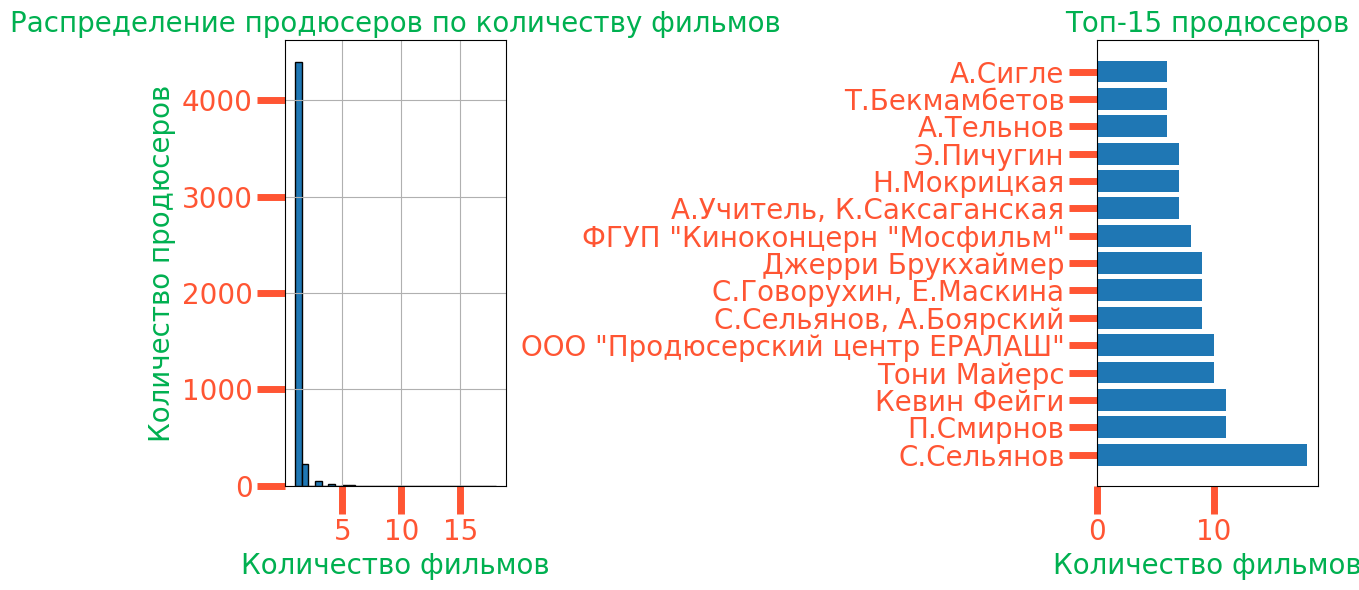

In [576]:
import matplotlib.pyplot as plt

# График распределения
plt.figure(figsize=(12, 6))

# Гистограмма количества фильмов на продюсера
plt.subplot(1, 2, 1)
producer_stats.hist(bins=30, edgecolor='black')
plt.title('Распределение продюсеров по количеству фильмов')
plt.xlabel('Количество фильмов')
plt.ylabel('Количество продюсеров')

# Топ-15 продюсеров
plt.subplot(1, 2, 2)
top_15 = producer_stats.head(15)
plt.barh(range(len(top_15)), top_15.values)
plt.yticks(range(len(top_15)), top_15.index)
plt.title('Топ-15 продюсеров')
plt.xlabel('Количество фильмов')

plt.tight_layout()
plt.show()

In [577]:
# Создаем категориальную колонку
producer_counts = imdb['producer'].value_counts()

def categorize_producer(producer):
    if pd.isna(producer):
        return 'unknown'
    count = producer_counts.get(producer, 0)
    if count >= 10: return 'top_10+'
    elif count >= 5: return 'good_5-9'
    elif count >= 2: return 'regular_2-4'
    else: return 'single_1'

imdb['producer_category'] = imdb['producer'].apply(categorize_producer)

# Проверяем
print(imdb['producer_category'].value_counts())

producer_category
single_1       4403
regular_2-4     692
unknown         464
good_5-9        166
top_10+          60
Name: count, dtype: int64


In [578]:
imdb = imdb.drop('producer', axis=1)
imdb

,title,show_start_date,type,film_studio,production_country,director,age_restriction,refundable_support,nonrefundable_support,budget,financing_source,ratings,genres,box_office,producer_category
0,Я ПРЕПОД,2018-09-06T12:00:00.000Z,Художественный,Яш Радж Филмз,Индия,Сиддхартх Малхотра,«12+» - для детей старше 12 лет,NaN,NaN,NaN,None,7.8,"драма,комедия",145448.0,single_1
1,"""SOS"" над тайгой",2014-12-01T12:00:00.000Z,Художественный,"Киностудия ""Мосфильм""",СССР,"В.Перов, А.Кольцатый",«12+» - для детей старше 12 лет,NaN,NaN,NaN,None,6.7,"драма,криминал,приключения",0.0,unknown
2,"""V"" значит вендетта",2010-12-25T12:00:00.000Z,Художественный,"Уорнер Бразерс, Сильвер Пикчерз, Анархоз Прода...",США - Германия - Великобритания,Джеймс МакТэйг,«16+» - для детей старше 16 лет,NaN,NaN,NaN,None,7.8,"фантастика,боевик,триллер",0.0,regular_2-4
3,"""Машины песенки"". Серия ""Опять Новый Год!""",2019-11-15T12:00:00.000Z,Анимационный,"Анимаккорд Лтд, ООО Студия ""АНИМАККОРД""",Республика Кипр-Россия,Роман Козич,«0+» - для любой зрительской аудитории,NaN,NaN,NaN,None,5.9,"короткометражка,драма,триллер",0.0,regular_2-4
4,"""Море""",2013-03-13T12:00:00.000Z,Художественный,"ООО ""ТПО ""РОК"", ООО ""Коломна""",Россия,А.Стреляная,«16+» - для детей старше 16 лет,NaN,NaN,NaN,None,6.1,"триллер,драма,детектив",0.0,regular_2-4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5780,Ядовитая роза,2019-05-23T12:00:00.000Z,Художественный,Миллениум Медиа,США - Италия,"Джордж Галло, Франческо Синкуемани",«18+» - запрещено для детей,NaN,NaN,NaN,None,5.2,триллер,8523922.5,single_1
5781,Яна + Янко,2017-01-20T12:00:00.000Z,Художественный,"ООО ""Магнум-фильм""",Россия,Н.Меркулова,«12+» - для детей старше 12 лет,15000000.0,28500000.0,68809226.0,Фонд кино,6.2,"комедия,семейный",1802175.0,single_1
5782,Ярослав,2010-09-06T12:00:00.000Z,Художественный,"ООО ""Анно Домини. Агентство стиля""",Россия,Д.Коробкин,«16+» - для детей старше 16 лет,NaN,NaN,NaN,None,5.7,"приключения,история",2855.0,single_1
5783,Ярость / Fury,2014-10-10T12:00:00.000Z,Художественный,"Коламбиа Пикчерз, Кью И Ди Интернэшнл, Эл Стар...",США - Великобритания - КНР,Дэвид Эйр,«16+» - для детей старше 16 лет,NaN,NaN,NaN,None,7.4,"боевик,драма,военный",400.0,single_1


Есть пропуски:
- refundable_support       5471
- nonrefundable_support    5471
- budget                   5471
- financing_source         5471

как будто это можно удалить, у нас всего 5785 строк
- refundable_support — объём возвратных средств государственной поддержки;
- nonrefundable_support — объём невозвратных средств государственной поддержки;
- financing_source — источник государственного финансирования;

Я удалю их пожалуй, это составляет около 95 % пропусков, как будто бесполезно для анализа с учетом тако пустоты в остальной таблицы

In [579]:
imdb = imdb.drop(['refundable_support', 'nonrefundable_support', 'budget', 'financing_source'], axis=1)
imdb.head()

,title,show_start_date,type,film_studio,production_country,director,age_restriction,ratings,genres,box_office,producer_category
0,Я ПРЕПОД,2018-09-06T12:00:00.000Z,Художественный,Яш Радж Филмз,Индия,Сиддхартх Малхотра,«12+» - для детей старше 12 лет,7.8,"драма,комедия",145448.0,single_1
1,"""SOS"" над тайгой",2014-12-01T12:00:00.000Z,Художественный,"Киностудия ""Мосфильм""",СССР,"В.Перов, А.Кольцатый",«12+» - для детей старше 12 лет,6.7,"драма,криминал,приключения",0.0,unknown
2,"""V"" значит вендетта",2010-12-25T12:00:00.000Z,Художественный,"Уорнер Бразерс, Сильвер Пикчерз, Анархоз Прода...",США - Германия - Великобритания,Джеймс МакТэйг,«16+» - для детей старше 16 лет,7.8,"фантастика,боевик,триллер",0.0,regular_2-4
3,"""Машины песенки"". Серия ""Опять Новый Год!""",2019-11-15T12:00:00.000Z,Анимационный,"Анимаккорд Лтд, ООО Студия ""АНИМАККОРД""",Республика Кипр-Россия,Роман Козич,«0+» - для любой зрительской аудитории,5.9,"короткометражка,драма,триллер",0.0,regular_2-4
4,"""Море""",2013-03-13T12:00:00.000Z,Художественный,"ООО ""ТПО ""РОК"", ООО ""Коломна""",Россия,А.Стреляная,«16+» - для детей старше 16 лет,6.1,"триллер,драма,детектив",0.0,regular_2-4


In [580]:
genres_split = imdb['genres'].str.split(',', expand=True)
unique_genres = pd.unique(genres_split.values.ravel())
print(unique_genres)
print(len(unique_genres))

['драма' 'комедия' None 'криминал' 'приключения' 'фантастика' 'боевик'
 'триллер' 'короткометражка' 'детектив' 'мелодрама' 'мультфильм' 'детский'
 'фэнтези' 'документальный' 'ужасы' 'биография' 'история' 'семейный'
 'военный' 'музыка' 'концерт' 'аниме' 'спорт' 'мюзикл' 'реальное ТВ'
 'вестерн' 'фильм-нуар' 'новости' 'для взрослых']
30


In [581]:
imdb[imdb['genres'].isna()]

,title,show_start_date,type,film_studio,production_country,director,age_restriction,ratings,genres,box_office,producer_category
298,Аномия,2016-03-11T12:00:00.000Z,Художественный,Козлов Владимир Владимирович,Россия,В.Козлов,«18+» - запрещено для детей,4.3,None,0.0,single_1
2436,Курьезы,2019-10-18T12:00:00.000Z,Художественный,"АНО ""Кинофорум""",Россия,А.Мышкин,«16+» - для детей старше 16 лет,5.0,None,0.0,single_1
4235,РУССКОЕ КРАТКОЕ. Выпуск 3,2019-03-15T12:00:00.000Z,Художественный,Архангельская Региональная молодежная обществе...,Россия,"С.Сафонова, А.Хмельницкая, А.Сальянов, Н.Назар...",«16+» - для детей старше 16 лет,5.5,None,0.0,regular_2-4
4398,Русское краткое. Выпуск 4,2019-07-16T12:00:00.000Z,Художественный,"ИП Дибцева О.Н., ИП Булгаков Д.А., ООО ""Киноко...",Россия,"О.Дибцева, Д.Булгаков, А.Ильин, А.Шабаров, А.Б...",«16+» - для детей старше 16 лет,5.2,None,0.0,regular_2-4
4481,Сборник короткого метра. Оскар. Фильмы. 2017,2017-03-03T12:00:00.000Z,Художественный,"Куалиа Филмз, Марвин и Вейн, Эм энд Эм Продакш...",Франция - Испания - Дания - Венгрия - Швейцария,"С.Азази, Х.Г.Пене, К.Дик, Т. вон Гюнтен",«16+» - для детей старше 16 лет,7.5,None,2322497.0,single_1
4482,Сборник короткометражек Кинотавра 18+,2016-08-19T12:00:00.000Z,Художественный,"ООО ""Кинометр""",Россия,"И.Каграманов, А.Наумов, С.Осипьян, В.Валиуллин...",«18+» - запрещено для детей,5.2,None,1104161.0,single_1


удалю, посмотрел, что это такое, мне кажется, нельзя интерпретировать жанры

In [582]:
imdb = imdb[~imdb['genres'].isna()]

In [583]:
if imdb['genres'].isna().sum() == 0:
  print('пропусков не осталось')

пропусков не осталось


In [584]:
imdb.isna().sum()

,0
title,0
show_start_date,0
type,0
film_studio,5
production_country,0
director,0
age_restriction,0
ratings,0
genres,0
box_office,0


Пропусков не осталось, хотя про бокс офис не так все однозначно,ведь фильмы с 0 прокатом это либо фильмы, которые и не выходили в прокат, или же до нас не дошла эта информация из предоставленного датасета про сборы

## обработка данных

План следующий:
1. Для жанров можно создать OHE
2. Для типов аналогично
3. Страны просто привели к читаемому виду
4. Для возрастных ограничений OHE
5. Для даты выхода полезные фичи извлечем
6. Не знаю, как поступить со студиями и режиссерами, я посмотрел, что тот же warner встречается не так часто, поэтому отмечать по топам не знаю, на сколько правильно или нет, пока оставлю, как есть, мб потом поправлю
7.

In [585]:
### 1. OHE for genres
# Разбиваем жанры по запятым
genres_split = imdb['genres'].str.split(',', expand=False)
genres_ohe = pd.get_dummies(genres_split.explode()).groupby(level=0).max()

# Объединяем с исходным датасетом и удаляем номинальную колонку
imdb = pd.concat([imdb, genres_ohe], axis=1).drop('genres', axis=1)

imdb.head()

,title,show_start_date,type,film_studio,production_country,director,age_restriction,ratings,box_office,producer_category,...,новости,приключения,реальное ТВ,семейный,спорт,триллер,ужасы,фантастика,фильм-нуар,фэнтези
0,Я ПРЕПОД,2018-09-06T12:00:00.000Z,Художественный,Яш Радж Филмз,Индия,Сиддхартх Малхотра,«12+» - для детей старше 12 лет,7.8,145448.0,single_1,...,False,False,False,False,False,False,False,False,False,False
1,"""SOS"" над тайгой",2014-12-01T12:00:00.000Z,Художественный,"Киностудия ""Мосфильм""",СССР,"В.Перов, А.Кольцатый",«12+» - для детей старше 12 лет,6.7,0.0,unknown,...,False,True,False,False,False,False,False,False,False,False
2,"""V"" значит вендетта",2010-12-25T12:00:00.000Z,Художественный,"Уорнер Бразерс, Сильвер Пикчерз, Анархоз Прода...",США - Германия - Великобритания,Джеймс МакТэйг,«16+» - для детей старше 16 лет,7.8,0.0,regular_2-4,...,False,False,False,False,False,True,False,True,False,False
3,"""Машины песенки"". Серия ""Опять Новый Год!""",2019-11-15T12:00:00.000Z,Анимационный,"Анимаккорд Лтд, ООО Студия ""АНИМАККОРД""",Республика Кипр-Россия,Роман Козич,«0+» - для любой зрительской аудитории,5.9,0.0,regular_2-4,...,False,False,False,False,False,True,False,False,False,False
4,"""Море""",2013-03-13T12:00:00.000Z,Художественный,"ООО ""ТПО ""РОК"", ООО ""Коломна""",Россия,А.Стреляная,«16+» - для детей старше 16 лет,6.1,0.0,regular_2-4,...,False,False,False,False,False,True,False,False,False,False


In [586]:
imdb['type'].unique()

array([' Художественный', 'Художественный', 'Анимационный',
       'Научно-популярный', 'Прочие', 'Документальный',
       'Музыкально-развлекательный', ' Анимационный'], dtype=object)

In [587]:
imdb['type'] = imdb['type'].str.strip()

In [588]:
### 2. OHE для типов фильмов
imdb['type'].unique()

array(['Художественный', 'Анимационный', 'Научно-популярный', 'Прочие',
       'Документальный', 'Музыкально-развлекательный'], dtype=object)

In [589]:
ohe_type = pd.get_dummies(imdb['type'], prefix='type', drop_first=True)
imdb = pd.concat((imdb.drop('type', axis=1), ohe_type), axis=1)
imdb

,title,show_start_date,film_studio,production_country,director,age_restriction,ratings,box_office,producer_category,аниме,...,триллер,ужасы,фантастика,фильм-нуар,фэнтези,type_Документальный,type_Музыкально-развлекательный,type_Научно-популярный,type_Прочие,type_Художественный
0,Я ПРЕПОД,2018-09-06T12:00:00.000Z,Яш Радж Филмз,Индия,Сиддхартх Малхотра,«12+» - для детей старше 12 лет,7.8,145448.0,single_1,False,...,False,False,False,False,False,False,False,False,False,True
1,"""SOS"" над тайгой",2014-12-01T12:00:00.000Z,"Киностудия ""Мосфильм""",СССР,"В.Перов, А.Кольцатый",«12+» - для детей старше 12 лет,6.7,0.0,unknown,False,...,False,False,False,False,False,False,False,False,False,True
2,"""V"" значит вендетта",2010-12-25T12:00:00.000Z,"Уорнер Бразерс, Сильвер Пикчерз, Анархоз Прода...",США - Германия - Великобритания,Джеймс МакТэйг,«16+» - для детей старше 16 лет,7.8,0.0,regular_2-4,False,...,True,False,True,False,False,False,False,False,False,True
3,"""Машины песенки"". Серия ""Опять Новый Год!""",2019-11-15T12:00:00.000Z,"Анимаккорд Лтд, ООО Студия ""АНИМАККОРД""",Республика Кипр-Россия,Роман Козич,«0+» - для любой зрительской аудитории,5.9,0.0,regular_2-4,False,...,True,False,False,False,False,False,False,False,False,False
4,"""Море""",2013-03-13T12:00:00.000Z,"ООО ""ТПО ""РОК"", ООО ""Коломна""",Россия,А.Стреляная,«16+» - для детей старше 16 лет,6.1,0.0,regular_2-4,False,...,True,False,False,False,False,False,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5780,Ядовитая роза,2019-05-23T12:00:00.000Z,Миллениум Медиа,США - Италия,"Джордж Галло, Франческо Синкуемани",«18+» - запрещено для детей,5.2,8523922.5,single_1,False,...,True,False,False,False,False,False,False,False,False,True
5781,Яна + Янко,2017-01-20T12:00:00.000Z,"ООО ""Магнум-фильм""",Россия,Н.Меркулова,«12+» - для детей старше 12 лет,6.2,1802175.0,single_1,False,...,False,False,False,False,False,False,False,False,False,True
5782,Ярослав,2010-09-06T12:00:00.000Z,"ООО ""Анно Домини. Агентство стиля""",Россия,Д.Коробкин,«16+» - для детей старше 16 лет,5.7,2855.0,single_1,False,...,False,False,False,False,False,False,False,False,False,True
5783,Ярость / Fury,2014-10-10T12:00:00.000Z,"Коламбиа Пикчерз, Кью И Ди Интернэшнл, Эл Стар...",США - Великобритания - КНР,Дэвид Эйр,«16+» - для детей старше 16 лет,7.4,400.0,single_1,False,...,False,False,False,False,False,False,False,False,False,True


In [590]:
### 3.
# теккст
imdb['production_country'] = imdb['production_country'].str.lower().str.strip()
imdb['production_country'] = imdb['production_country'].str.replace(' - ', ' ')
imdb['production_country'] = imdb['production_country'].str.replace('-', ' ')

# Смотрим на уникальные значения
print("Уникальные страны:")
print(imdb['production_country'].value_counts().head(20))

print(f"\nВсего уникальных комбинаций стран: {imdb['production_country'].nunique()}")

Уникальные страны:
production_country
сша                   1709
россия                1253
ссср                   359
франция                267
великобритания         174
германия                85
сша великобритания      77
япония                  71
италия                  70
испания                 63
франция бельгия         53
великобритания сша      46
сша австралия           43
канада                  40
сша канада              39
австралия               38
сша германия            36
сша франция             31
кнр                     26
южная корея             20
Name: count, dtype: int64

Всего уникальных комбинаций стран: 781


In [591]:
imdb

,title,show_start_date,film_studio,production_country,director,age_restriction,ratings,box_office,producer_category,аниме,...,триллер,ужасы,фантастика,фильм-нуар,фэнтези,type_Документальный,type_Музыкально-развлекательный,type_Научно-популярный,type_Прочие,type_Художественный
0,Я ПРЕПОД,2018-09-06T12:00:00.000Z,Яш Радж Филмз,индия,Сиддхартх Малхотра,«12+» - для детей старше 12 лет,7.8,145448.0,single_1,False,...,False,False,False,False,False,False,False,False,False,True
1,"""SOS"" над тайгой",2014-12-01T12:00:00.000Z,"Киностудия ""Мосфильм""",ссср,"В.Перов, А.Кольцатый",«12+» - для детей старше 12 лет,6.7,0.0,unknown,False,...,False,False,False,False,False,False,False,False,False,True
2,"""V"" значит вендетта",2010-12-25T12:00:00.000Z,"Уорнер Бразерс, Сильвер Пикчерз, Анархоз Прода...",сша германия великобритания,Джеймс МакТэйг,«16+» - для детей старше 16 лет,7.8,0.0,regular_2-4,False,...,True,False,True,False,False,False,False,False,False,True
3,"""Машины песенки"". Серия ""Опять Новый Год!""",2019-11-15T12:00:00.000Z,"Анимаккорд Лтд, ООО Студия ""АНИМАККОРД""",республика кипр россия,Роман Козич,«0+» - для любой зрительской аудитории,5.9,0.0,regular_2-4,False,...,True,False,False,False,False,False,False,False,False,False
4,"""Море""",2013-03-13T12:00:00.000Z,"ООО ""ТПО ""РОК"", ООО ""Коломна""",россия,А.Стреляная,«16+» - для детей старше 16 лет,6.1,0.0,regular_2-4,False,...,True,False,False,False,False,False,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5780,Ядовитая роза,2019-05-23T12:00:00.000Z,Миллениум Медиа,сша италия,"Джордж Галло, Франческо Синкуемани",«18+» - запрещено для детей,5.2,8523922.5,single_1,False,...,True,False,False,False,False,False,False,False,False,True
5781,Яна + Янко,2017-01-20T12:00:00.000Z,"ООО ""Магнум-фильм""",россия,Н.Меркулова,«12+» - для детей старше 12 лет,6.2,1802175.0,single_1,False,...,False,False,False,False,False,False,False,False,False,True
5782,Ярослав,2010-09-06T12:00:00.000Z,"ООО ""Анно Домини. Агентство стиля""",россия,Д.Коробкин,«16+» - для детей старше 16 лет,5.7,2855.0,single_1,False,...,False,False,False,False,False,False,False,False,False,True
5783,Ярость / Fury,2014-10-10T12:00:00.000Z,"Коламбиа Пикчерз, Кью И Ди Интернэшнл, Эл Стар...",сша великобритания кнр,Дэвид Эйр,«16+» - для детей старше 16 лет,7.4,400.0,single_1,False,...,False,False,False,False,False,False,False,False,False,True


In [592]:
### 4.
imdb['age_restriction'].unique()

array(['«12+» - для детей старше 12 лет',
       '«16+» - для детей старше 16 лет',
       '«0+» - для любой зрительской аудитории',
       '«6+» - для детей старше 6 лет', '«18+» - запрещено для детей'],
      dtype=object)

In [593]:
# 4. One-Hot Encoding для возрастных категорий
ohe_age = pd.get_dummies(imdb['age_restriction'], prefix='age', drop_first=True)
imdb = pd.concat([imdb.drop('age_restriction', axis=1), ohe_age], axis=1)
imdb

,title,show_start_date,film_studio,production_country,director,ratings,box_office,producer_category,аниме,биография,...,фэнтези,type_Документальный,type_Музыкально-развлекательный,type_Научно-популярный,type_Прочие,type_Художественный,age_«12+» - для детей старше 12 лет,age_«16+» - для детей старше 16 лет,age_«18+» - запрещено для детей,age_«6+» - для детей старше 6 лет
0,Я ПРЕПОД,2018-09-06T12:00:00.000Z,Яш Радж Филмз,индия,Сиддхартх Малхотра,7.8,145448.0,single_1,False,False,...,False,False,False,False,False,True,True,False,False,False
1,"""SOS"" над тайгой",2014-12-01T12:00:00.000Z,"Киностудия ""Мосфильм""",ссср,"В.Перов, А.Кольцатый",6.7,0.0,unknown,False,False,...,False,False,False,False,False,True,True,False,False,False
2,"""V"" значит вендетта",2010-12-25T12:00:00.000Z,"Уорнер Бразерс, Сильвер Пикчерз, Анархоз Прода...",сша германия великобритания,Джеймс МакТэйг,7.8,0.0,regular_2-4,False,False,...,False,False,False,False,False,True,False,True,False,False
3,"""Машины песенки"". Серия ""Опять Новый Год!""",2019-11-15T12:00:00.000Z,"Анимаккорд Лтд, ООО Студия ""АНИМАККОРД""",республика кипр россия,Роман Козич,5.9,0.0,regular_2-4,False,False,...,False,False,False,False,False,False,False,False,False,False
4,"""Море""",2013-03-13T12:00:00.000Z,"ООО ""ТПО ""РОК"", ООО ""Коломна""",россия,А.Стреляная,6.1,0.0,regular_2-4,False,False,...,False,False,False,False,False,True,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5780,Ядовитая роза,2019-05-23T12:00:00.000Z,Миллениум Медиа,сша италия,"Джордж Галло, Франческо Синкуемани",5.2,8523922.5,single_1,False,False,...,False,False,False,False,False,True,False,False,True,False
5781,Яна + Янко,2017-01-20T12:00:00.000Z,"ООО ""Магнум-фильм""",россия,Н.Меркулова,6.2,1802175.0,single_1,False,False,...,False,False,False,False,False,True,True,False,False,False
5782,Ярослав,2010-09-06T12:00:00.000Z,"ООО ""Анно Домини. Агентство стиля""",россия,Д.Коробкин,5.7,2855.0,single_1,False,False,...,False,False,False,False,False,True,False,True,False,False
5783,Ярость / Fury,2014-10-10T12:00:00.000Z,"Коламбиа Пикчерз, Кью И Ди Интернэшнл, Эл Стар...",сша великобритания кнр,Дэвид Эйр,7.4,400.0,single_1,False,False,...,False,False,False,False,False,True,False,True,False,False


In [594]:
### 5. time
imdb['show_start_date'] = pd.to_datetime(imdb['show_start_date'])

In [595]:
# Извлекаем полезные фичи
imdb['release_year'] = imdb['show_start_date'].dt.year
imdb['release_month'] = imdb['show_start_date'].dt.month
imdb['release_quarter'] = imdb['show_start_date'].dt.quarter
imdb['release_dayofweek'] = imdb['show_start_date'].dt.dayofweek
imdb['is_weekend'] = imdb['show_start_date'].dt.dayofweek.isin([5, 6]).astype(int)

In [596]:
imdb = imdb.drop('show_start_date', axis=1)
imdb

,title,film_studio,production_country,director,ratings,box_office,producer_category,аниме,биография,боевик,...,type_Художественный,age_«12+» - для детей старше 12 лет,age_«16+» - для детей старше 16 лет,age_«18+» - запрещено для детей,age_«6+» - для детей старше 6 лет,release_year,release_month,release_quarter,release_dayofweek,is_weekend
0,Я ПРЕПОД,Яш Радж Филмз,индия,Сиддхартх Малхотра,7.8,145448.0,single_1,False,False,False,...,True,True,False,False,False,2018,9,3,3,0
1,"""SOS"" над тайгой","Киностудия ""Мосфильм""",ссср,"В.Перов, А.Кольцатый",6.7,0.0,unknown,False,False,False,...,True,True,False,False,False,2014,12,4,0,0
2,"""V"" значит вендетта","Уорнер Бразерс, Сильвер Пикчерз, Анархоз Прода...",сша германия великобритания,Джеймс МакТэйг,7.8,0.0,regular_2-4,False,False,True,...,True,False,True,False,False,2010,12,4,5,1
3,"""Машины песенки"". Серия ""Опять Новый Год!""","Анимаккорд Лтд, ООО Студия ""АНИМАККОРД""",республика кипр россия,Роман Козич,5.9,0.0,regular_2-4,False,False,False,...,False,False,False,False,False,2019,11,4,4,0
4,"""Море""","ООО ""ТПО ""РОК"", ООО ""Коломна""",россия,А.Стреляная,6.1,0.0,regular_2-4,False,False,False,...,True,False,True,False,False,2013,3,1,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5780,Ядовитая роза,Миллениум Медиа,сша италия,"Джордж Галло, Франческо Синкуемани",5.2,8523922.5,single_1,False,False,False,...,True,False,False,True,False,2019,5,2,3,0
5781,Яна + Янко,"ООО ""Магнум-фильм""",россия,Н.Меркулова,6.2,1802175.0,single_1,False,False,False,...,True,True,False,False,False,2017,1,1,4,0
5782,Ярослав,"ООО ""Анно Домини. Агентство стиля""",россия,Д.Коробкин,5.7,2855.0,single_1,False,False,False,...,True,False,True,False,False,2010,9,3,0,0
5783,Ярость / Fury,"Коламбиа Пикчерз, Кью И Ди Интернэшнл, Эл Стар...",сша великобритания кнр,Дэвид Эйр,7.4,400.0,single_1,False,False,True,...,True,False,True,False,False,2014,10,4,4,0


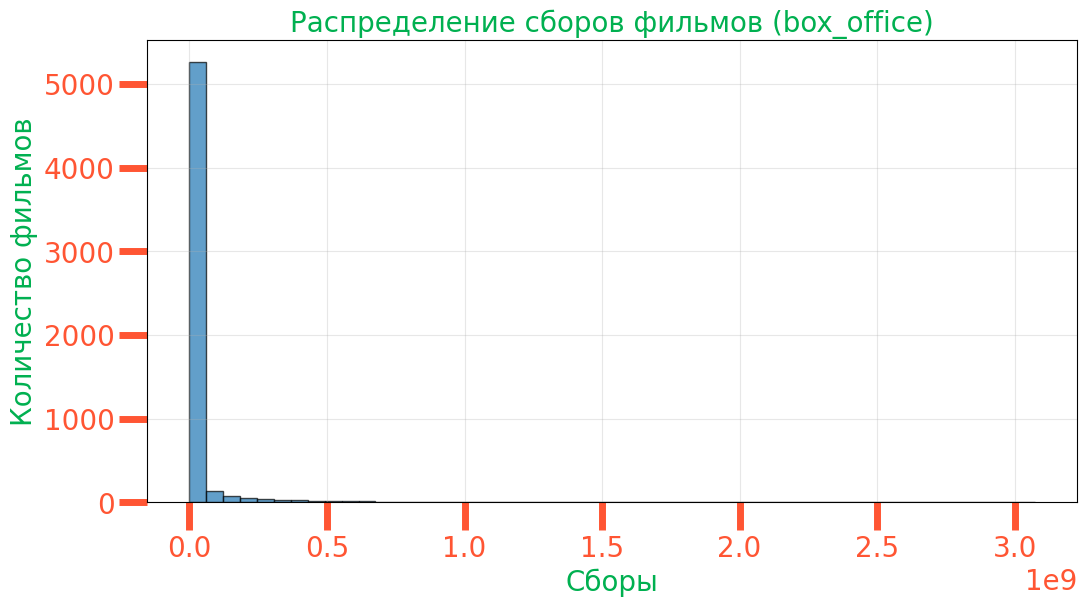

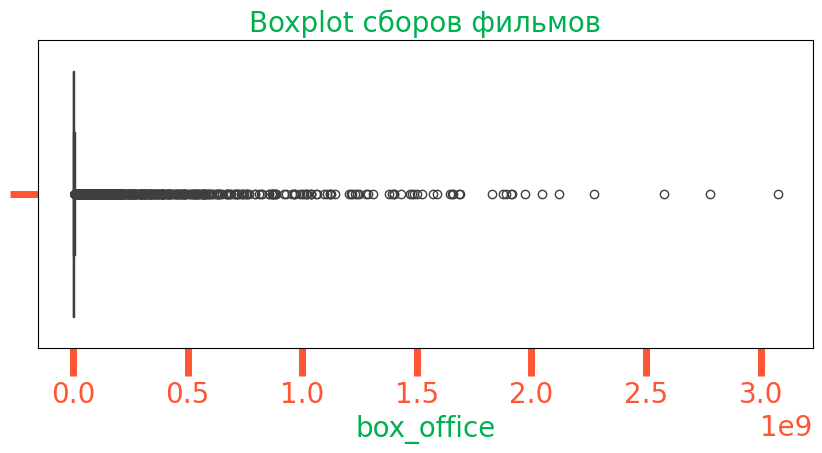

In [597]:
import matplotlib.pyplot as plt
import seaborn as sns

# Гистограмма box_office (только положительные сборы)
plt.figure(figsize=(12, 6))
plt.hist(imdb['box_office'], bins=50, edgecolor='black', alpha=0.7)
plt.title('Распределение сборов фильмов (box_office)')
plt.xlabel('Сборы')
plt.ylabel('Количество фильмов')
plt.grid(True, alpha=0.3)
plt.show()

# Боксплот для выбросов (только положительные сборы)
plt.figure(figsize=(10, 4))
sns.boxplot(x=imdb['box_office'])
plt.title('Boxplot сборов фильмов')
plt.show()

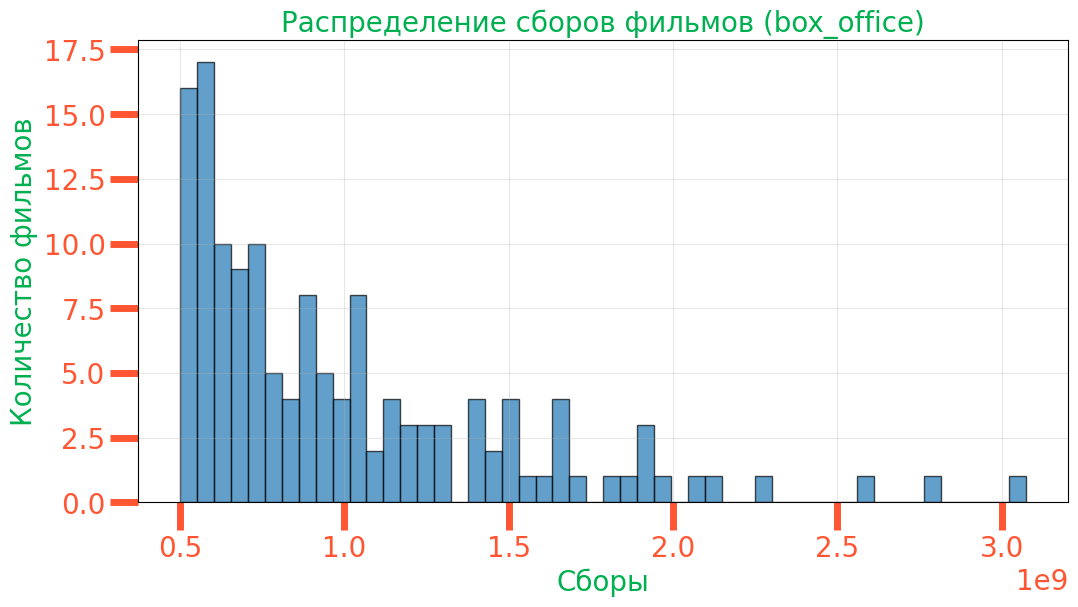

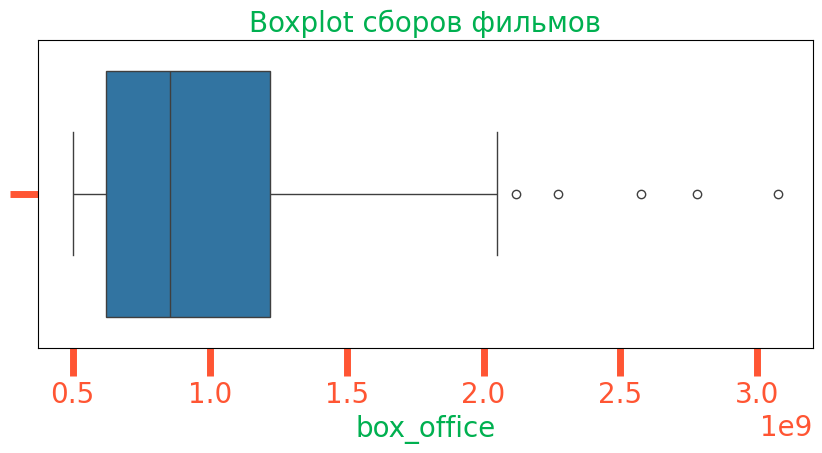

In [598]:
import matplotlib.pyplot as plt
import seaborn as sns

# Гистограмма box_office (только положительные сборы)
plt.figure(figsize=(12, 6))
plt.hist(imdb[imdb['box_office'] > 500000000]['box_office'], bins=50, edgecolor='black', alpha=0.7)
plt.title('Распределение сборов фильмов (box_office)')
plt.xlabel('Сборы')
plt.ylabel('Количество фильмов')
plt.grid(True, alpha=0.3)
plt.show()

# Боксплот для выбросов (только положительные сборы)
plt.figure(figsize=(10, 4))
sns.boxplot(x=imdb[imdb['box_office'] > 500000000]['box_office'])
plt.title('Boxplot сборов фильмов')
plt.show()

У половины фильмов вовсе нет сборов из-за нехватки данных, поэтому ноль стоит, наблюдаются редкие случаи колоссальных сборов, блокбастеры какие-то,  я бы ничего не менял, кроме того, что сделал бы разметки о том, что колоссальные сборы, не был в прокате, низкие сборы, средние, высокие, а цифры удалю

In [599]:
# Сначала посмотрим распределение среди фильмов с ненулевыми сборами
positive_box_office = imdb[imdb['box_office'] > 0]['box_office']

print("СТАТИСТИКА ПО НЕНУЛЕВЫМ СБОРАМ:")
print("=" * 50)
print(f"Всего фильмов: {len(imdb)}")
print(f"Фильмов с нулевыми сборами: {len(imdb[imdb['box_office'] == 0])}")
print(f"Фильмов с положительными сборами: {len(positive_box_office)}")
print(f"Медиана сборов: {positive_box_office.median():,.0f}")
print(f"Средние сборы: {positive_box_office.mean():,.0f}")

# Квантили для разделения на категории
quantiles = positive_box_office.quantile([0.1,0.33, 0.66, 0.8, 0.9, 0.99])

print(f"\nПЕРЦЕНТИЛИ И КОЛИЧЕСТВО ФИЛЬМОВ:")
print("=" * 50)
percentiles = [0.1,0.33, 0.66, 0.8, 0.9, 0.99]

for p in percentiles:
    value = quantiles[p]
    count_below = len(positive_box_office[positive_box_office <= value])
    count_above = len(positive_box_office[positive_box_office > value])
    print(f"{int(p*100)}-й перцентиль: {value:,.0f} | Фильмов до: {count_below} | Фильмов после: {count_above}")

# Дополнительно: топ-10 самых кассовых фильмов
print(f"\nТОП-10 САМЫХ КАССОВЫХ ФИЛЬМОВ:")
top_10 = imdb.nlargest(10, 'box_office')[['title', 'box_office']]
for idx, row in top_10.iterrows():
    print(f"{row['title']}: {row['box_office']:,.0f}")

СТАТИСТИКА ПО НЕНУЛЕВЫМ СБОРАМ:
Всего фильмов: 5779
Фильмов с нулевыми сборами: 2931
Фильмов с положительными сборами: 2848
Медиана сборов: 2,862,158
Средние сборы: 81,462,653

ПЕРЦЕНТИЛИ И КОЛИЧЕСТВО ФИЛЬМОВ:
10-й перцентиль: 2,010 | Фильмов до: 285 | Фильмов после: 2563
33-й перцентиль: 571,245 | Фильмов до: 940 | Фильмов после: 1908
66-й перцентиль: 12,261,374 | Фильмов до: 1880 | Фильмов после: 968
80-й перцентиль: 51,940,067 | Фильмов до: 2278 | Фильмов после: 570
90-й перцентиль: 200,717,431 | Фильмов до: 2563 | Фильмов после: 285
99-й перцентиль: 1,344,074,598 | Фильмов до: 2819 | Фильмов после: 29

ТОП-10 САМЫХ КАССОВЫХ ФИЛЬМОВ:
Холоп: 3,073,568,691
Движение вверх: 2,779,686,144
Мстители: Финал: 2,576,613,777
Т-34: 2,271,754,005
Пираты Карибского моря: Мертвецы не рассказывают сказки: 2,118,396,119
Зверополис: 2,048,126,958
Тайная жизнь домашних животных. Миньоны против газона: 1,971,005,085
Веном: 1,913,257,923
Малефисента: Владычица тьмы: 1,911,944,866
Джокер: 1,890,368,076


In [600]:
# Создаем категории по новым правилам
def categorize_box_office(revenue):
    if revenue == 0:
        return 'не_был_в_прокате'
    elif revenue <= quantiles[0.33]:
        return 'низкие_сборы'
    elif revenue <= quantiles[0.66]:
        return 'средние_сборы'
    elif revenue <= quantiles[0.9]:
        return 'выше_среднего'
    else:
        return 'колоссальные_сборы'

imdb['box_office_category'] = imdb['box_office'].apply(categorize_box_office)

# Статистика по новым категориям
print("РАСПРЕДЕЛЕНИЕ ПО НОВЫМ КАТЕГОРИЯМ:")
print("=" * 50)
category_stats = imdb['box_office_category'].value_counts()
for category, count in category_stats.items():
    percentage = (count / len(imdb)) * 100
    print(f"{category}: {count} фильмов ({percentage:.1f}%)")

print(f"\nИтоговое количество фильмов в каждой категории:")
positive_films = imdb[imdb['box_office_category'] != 'не_был_в_прокате']
for category in ['низкие_сборы', 'средние_сборы', 'выше_среднего', 'колоссальные_сборы']:
    count = len(positive_films[positive_films['box_office_category'] == category])
    total_positive = len(positive_films)
    percentage = (count / total_positive) * 100
    print(f"{category}: {count} фильмов ({percentage:.1f}% от фильмов с данными о сборах)")

РАСПРЕДЕЛЕНИЕ ПО НОВЫМ КАТЕГОРИЯМ:
не_был_в_прокате: 2931 фильмов (50.7%)
низкие_сборы: 940 фильмов (16.3%)
средние_сборы: 940 фильмов (16.3%)
выше_среднего: 683 фильмов (11.8%)
колоссальные_сборы: 285 фильмов (4.9%)

Итоговое количество фильмов в каждой категории:
низкие_сборы: 940 фильмов (33.0% от фильмов с данными о сборах)
средние_сборы: 940 фильмов (33.0% от фильмов с данными о сборах)
выше_среднего: 683 фильмов (24.0% от фильмов с данными о сборах)
колоссальные_сборы: 285 фильмов (10.0% от фильмов с данными о сборах)


In [601]:
# Создаем OHE для категорий сборов
ohe_box_office = pd.get_dummies(imdb['box_office_category'], prefix='box_office', drop_first=True)

imdb = pd.concat([imdb.drop(['box_office', 'box_office_category'], axis=1), ohe_box_office], axis=1)

In [602]:
imdb

,title,film_studio,production_country,director,ratings,producer_category,аниме,биография,боевик,вестерн,...,age_«6+» - для детей старше 6 лет,release_year,release_month,release_quarter,release_dayofweek,is_weekend,box_office_колоссальные_сборы,box_office_не_был_в_прокате,box_office_низкие_сборы,box_office_средние_сборы
0,Я ПРЕПОД,Яш Радж Филмз,индия,Сиддхартх Малхотра,7.8,single_1,False,False,False,False,...,False,2018,9,3,3,0,False,False,True,False
1,"""SOS"" над тайгой","Киностудия ""Мосфильм""",ссср,"В.Перов, А.Кольцатый",6.7,unknown,False,False,False,False,...,False,2014,12,4,0,0,False,True,False,False
2,"""V"" значит вендетта","Уорнер Бразерс, Сильвер Пикчерз, Анархоз Прода...",сша германия великобритания,Джеймс МакТэйг,7.8,regular_2-4,False,False,True,False,...,False,2010,12,4,5,1,False,True,False,False
3,"""Машины песенки"". Серия ""Опять Новый Год!""","Анимаккорд Лтд, ООО Студия ""АНИМАККОРД""",республика кипр россия,Роман Козич,5.9,regular_2-4,False,False,False,False,...,False,2019,11,4,4,0,False,True,False,False
4,"""Море""","ООО ""ТПО ""РОК"", ООО ""Коломна""",россия,А.Стреляная,6.1,regular_2-4,False,False,False,False,...,False,2013,3,1,2,0,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5780,Ядовитая роза,Миллениум Медиа,сша италия,"Джордж Галло, Франческо Синкуемани",5.2,single_1,False,False,False,False,...,False,2019,5,2,3,0,False,False,False,True
5781,Яна + Янко,"ООО ""Магнум-фильм""",россия,Н.Меркулова,6.2,single_1,False,False,False,False,...,False,2017,1,1,4,0,False,False,False,True
5782,Ярослав,"ООО ""Анно Домини. Агентство стиля""",россия,Д.Коробкин,5.7,single_1,False,False,False,False,...,False,2010,9,3,0,0,False,False,True,False
5783,Ярость / Fury,"Коламбиа Пикчерз, Кью И Ди Интернэшнл, Эл Стар...",сша великобритания кнр,Дэвид Эйр,7.4,single_1,False,False,True,False,...,False,2014,10,4,4,0,False,False,True,False


In [604]:
### удалим названия
imdb = imdb.drop('title', axis=1)
imdb

,film_studio,production_country,director,ratings,producer_category,аниме,биография,боевик,вестерн,военный,...,age_«6+» - для детей старше 6 лет,release_year,release_month,release_quarter,release_dayofweek,is_weekend,box_office_колоссальные_сборы,box_office_не_был_в_прокате,box_office_низкие_сборы,box_office_средние_сборы
0,Яш Радж Филмз,индия,Сиддхартх Малхотра,7.8,single_1,False,False,False,False,False,...,False,2018,9,3,3,0,False,False,True,False
1,"Киностудия ""Мосфильм""",ссср,"В.Перов, А.Кольцатый",6.7,unknown,False,False,False,False,False,...,False,2014,12,4,0,0,False,True,False,False
2,"Уорнер Бразерс, Сильвер Пикчерз, Анархоз Прода...",сша германия великобритания,Джеймс МакТэйг,7.8,regular_2-4,False,False,True,False,False,...,False,2010,12,4,5,1,False,True,False,False
3,"Анимаккорд Лтд, ООО Студия ""АНИМАККОРД""",республика кипр россия,Роман Козич,5.9,regular_2-4,False,False,False,False,False,...,False,2019,11,4,4,0,False,True,False,False
4,"ООО ""ТПО ""РОК"", ООО ""Коломна""",россия,А.Стреляная,6.1,regular_2-4,False,False,False,False,False,...,False,2013,3,1,2,0,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5780,Миллениум Медиа,сша италия,"Джордж Галло, Франческо Синкуемани",5.2,single_1,False,False,False,False,False,...,False,2019,5,2,3,0,False,False,False,True
5781,"ООО ""Магнум-фильм""",россия,Н.Меркулова,6.2,single_1,False,False,False,False,False,...,False,2017,1,1,4,0,False,False,False,True
5782,"ООО ""Анно Домини. Агентство стиля""",россия,Д.Коробкин,5.7,single_1,False,False,False,False,False,...,False,2010,9,3,0,0,False,False,True,False
5783,"Коламбиа Пикчерз, Кью И Ди Интернэшнл, Эл Стар...",сша великобритания кнр,Дэвид Эйр,7.4,single_1,False,False,True,False,True,...,False,2014,10,4,4,0,False,False,True,False


In [606]:
imdb.dtypes

,0
film_studio,object
production_country,object
director,object
ratings,float64
producer_category,object
аниме,bool
биография,bool
боевик,bool
вестерн,bool
военный,bool


## ОБУЧЕНИЕ

In [612]:
categoric_columns =imdb.loc[:,imdb.dtypes==object].columns
categoric_columns

Index(['film_studio', 'production_country', 'director', 'producer_category'], dtype='object')

In [619]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from tensorflow import keras
from tensorflow.keras import layers

# Подготовка данных
X = imdb.drop('ratings', axis=1)
y = imdb['ratings']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Преобразуем bool колонки в int
bool_cols = X.select_dtypes(include=['bool']).columns
X[bool_cols] = X[bool_cols].astype(int)
X_train[bool_cols] = X_train[bool_cols].astype(int)
X_test[bool_cols] = X_test[bool_cols].astype(int)

# Разделяем колонки
object_cols = ['film_studio', 'production_country', 'director', 'producer_category']
numeric_cols = [col for col in X.columns if col not in object_cols]

# Создаем модель с эмбеддингами
inputs = []
embeddings = []

# Числовые колонки
numeric_input = layers.Input(shape=(len(numeric_cols),), name='numeric')
inputs.append(numeric_input)
embeddings.append(numeric_input)

# Эмбеддинги для object колонок
for col in object_cols:
    vocab_size = X[col].nunique()
    input_layer = layers.Input(shape=(1,), name=col)
    embedding = layers.Embedding(vocab_size + 1, 8)(input_layer)
    embedding = layers.Flatten()(embedding)
    inputs.append(input_layer)
    embeddings.append(embedding)

# Объединяем
combined = layers.Concatenate()(embeddings)
x = layers.Dense(128, activation='relu')(combined)
x = layers.Dropout(0.3)(x)
x = layers.Dense(64, activation='relu')(x)
x = layers.Dense(1)(x)

model = keras.Model(inputs=inputs, outputs=x)

# Подготовка данных
train_data = {'numeric': X_train[numeric_cols].values}
test_data = {'numeric': X_test[numeric_cols].values}

for col in object_cols:
    train_data[col] = X_train[col].astype('category').cat.codes.values
    test_data[col] = X_test[col].astype('category').cat.codes.values

# Обучение с RMSE метрикой
model.compile(optimizer='adam', loss='mse', metrics=[keras.metrics.RootMeanSquaredError()])
history = model.fit(train_data, y_train, validation_data=(test_data, y_test),
                    epochs=100, batch_size=32, verbose=1)

# Оценка RMSE
test_loss, test_rmse = model.evaluate(test_data, y_test, verbose=0)
print(f'Test RMSE: {test_rmse:.4f}')

Epoch 1/100
145/145 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 6978.8311 - root_mean_squared_error: 80.2821 - val_loss: 67.4168 - val_root_mean_squared_error: 8.2108
Epoch 2/100
145/145 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 366.6656 - root_mean_squared_error: 19.1093 - val_loss: 1.3355 - val_root_mean_squared_error: 1.1557
Epoch 3/100
145/145 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 178.0271 - root_mean_squared_error: 13.3108 - val_loss: 17.4418 - val_root_mean_squared_error: 4.1763
Epoch 4/100
145/145 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 77.6873 - root_mean_squared_error: 8.8043 - val_loss: 1.2045 - val_root_mean_squared_error: 1.0975
Epoch 5/100
145/145 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 46.4403 - root_mean_squared_error: 6.7999 - val_loss: 2.5882 - val_root_mean_squared_error: 1.6088
Epoch 6/100
145/145 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 26.0801 - root_mean_squared_error: 5.1060 - val_loss: 12.4112 - val_root_mean_squared_error: 3.5230
Epoch 7/100
145/145 ━━━━━━━━━━

## Доработка

Training: relu, dropout=0.0, batch_norm=True, batch_size=16
RMSE: 1.7012

Training: relu, dropout=0.0, batch_norm=True, batch_size=32
RMSE: 6.8042

Training: relu, dropout=0.0, batch_norm=True, batch_size=64
RMSE: 15.5706

Training: relu, dropout=0.0, batch_norm=False, batch_size=16
RMSE: 1.6847

Training: relu, dropout=0.0, batch_norm=False, batch_size=32
RMSE: 1.3632

Training: relu, dropout=0.0, batch_norm=False, batch_size=64
RMSE: 1.8169

Training: relu, dropout=0.2, batch_norm=True, batch_size=16
RMSE: 17.0674

Training: relu, dropout=0.2, batch_norm=True, batch_size=32
RMSE: 22.3532

Training: relu, dropout=0.2, batch_norm=True, batch_size=64
RMSE: 31.2751

Training: relu, dropout=0.2, batch_norm=False, batch_size=16
RMSE: 1.5992

Training: relu, dropout=0.2, batch_norm=False, batch_size=32
RMSE: 1.2729

Training: relu, dropout=0.2, batch_norm=False, batch_size=64
RMSE: 1.3229

Training: relu, dropout=0.3, batch_norm=True, batch_size=16
RMSE: 20.9379

Training: relu, dropout=0.3

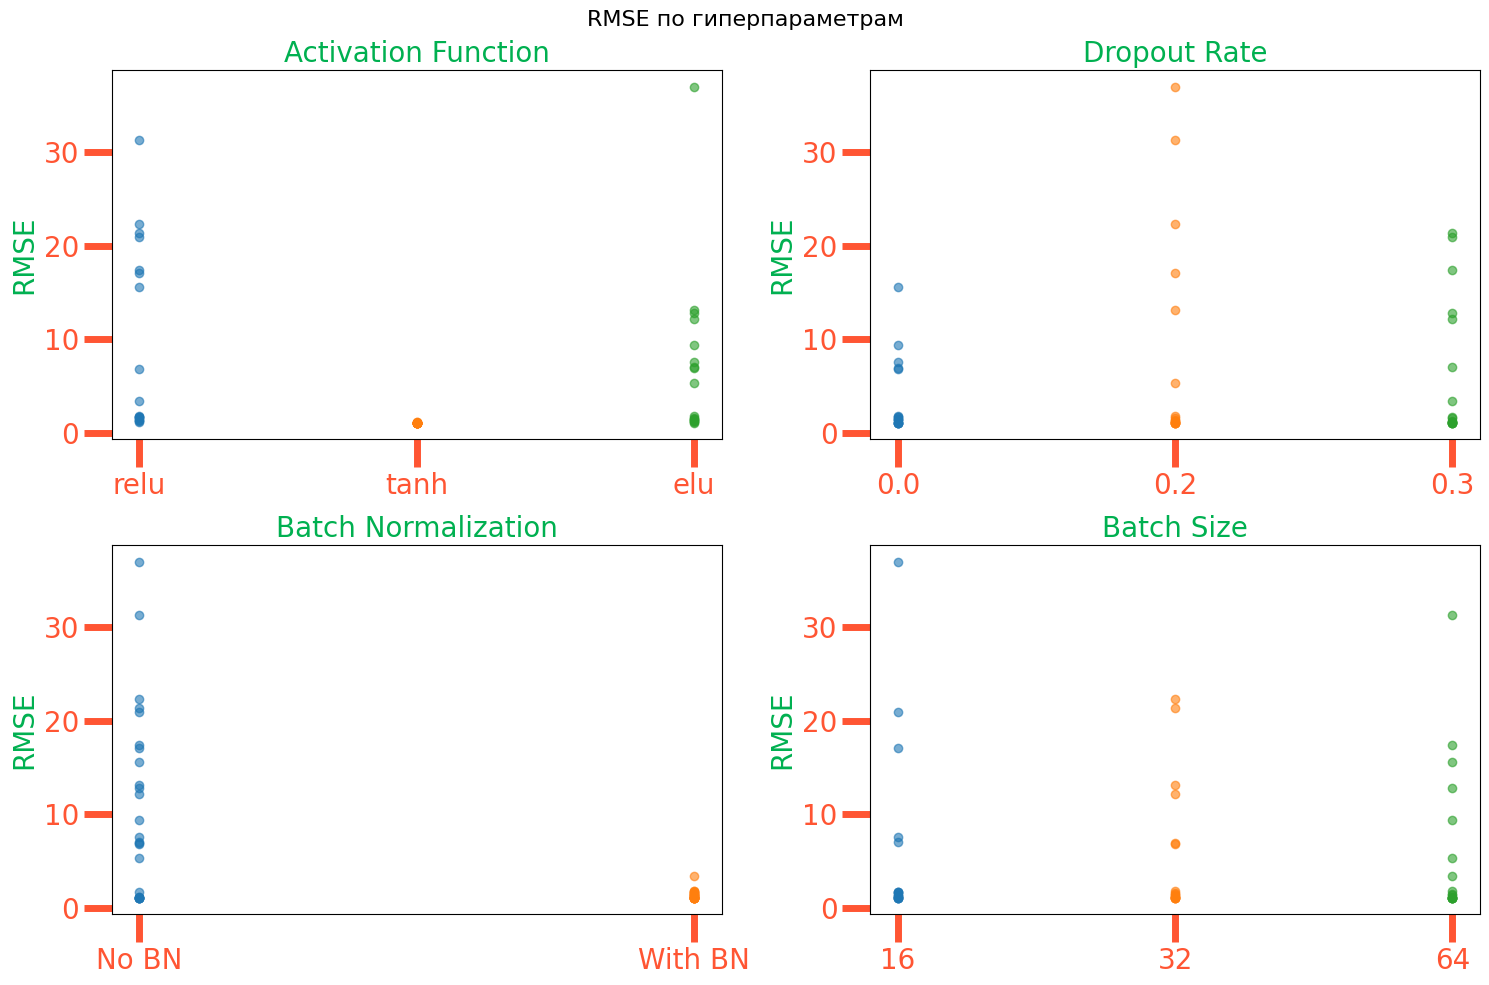

Лучшие параметры:
activation        tanh
dropout            0.2
batch_norm        True
batch_size          64
rmse          1.085867
Name: 26, dtype: object


In [617]:
# Параметры для grid search
param_grid = {
    'activation': ['relu', 'tanh', 'elu'],
    'dropout': [0.0, 0.2, 0.3],
    'batch_norm': [True, False],
    'batch_size': [16, 32, 64]
}

results = []

# Grid search
for activation in param_grid['activation']:
    for dropout_rate in param_grid['dropout']:
        for batch_norm in param_grid['batch_norm']:
            for batch_size in param_grid['batch_size']:

                print(f"Training: {activation}, dropout={dropout_rate}, batch_norm={batch_norm}, batch_size={batch_size}")

                # Создаем модель
                inputs = []
                embeddings = []

                numeric_input = layers.Input(shape=(len(numeric_cols),), name='numeric')
                inputs.append(numeric_input)
                embeddings.append(numeric_input)

                for col in object_cols:
                    vocab_size = X[col].nunique()
                    input_layer = layers.Input(shape=(1,), name=col)
                    embedding = layers.Embedding(vocab_size + 1, 8)(input_layer)
                    embedding = layers.Flatten()(embedding)
                    inputs.append(input_layer)
                    embeddings.append(embedding)

                combined = layers.Concatenate()(embeddings)
                x = layers.Dense(128, activation=activation)(combined)

                if batch_norm:
                    x = layers.BatchNormalization()(x)
                if dropout_rate > 0:
                    x = layers.Dropout(dropout_rate)(x)

                x = layers.Dense(64, activation=activation)(x)
                x = layers.Dense(1)(x)

                model = keras.Model(inputs=inputs, outputs=x)
                model.compile(optimizer='adam', loss='mse', metrics=['mae'])

                # Обучение
                history = model.fit(
                    train_data, y_train,
                    validation_data=(test_data, y_test),
                    epochs=30,
                    batch_size=batch_size,
                    verbose=0
                )

                # Оценка RMSE
                test_pred = model.predict(test_data, verbose=0)
                rmse = np.sqrt(np.mean((test_pred.flatten() - y_test.values) ** 2))

                results.append({
                    'activation': activation,
                    'dropout': dropout_rate,
                    'batch_norm': batch_norm,
                    'batch_size': batch_size,
                    'rmse': rmse
                })

                print(f"RMSE: {rmse:.4f}\n")

# Визуализация результатов
results_df = pd.DataFrame(results)

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('RMSE по гиперпараметрам', fontsize=16)

# Activation
for i, activation in enumerate(param_grid['activation']):
    activation_data = results_df[results_df['activation'] == activation]
    axes[0,0].scatter([i] * len(activation_data), activation_data['rmse'], alpha=0.6)
axes[0,0].set_title('Activation Function')
axes[0,0].set_xticks(range(len(param_grid['activation'])))
axes[0,0].set_xticklabels(param_grid['activation'])
axes[0,0].set_ylabel('RMSE')

# Dropout
for i, dropout in enumerate(param_grid['dropout']):
    dropout_data = results_df[results_df['dropout'] == dropout]
    axes[0,1].scatter([i] * len(dropout_data), dropout_data['rmse'], alpha=0.6)
axes[0,1].set_title('Dropout Rate')
axes[0,1].set_xticks(range(len(param_grid['dropout'])))
axes[0,1].set_xticklabels(param_grid['dropout'])
axes[0,1].set_ylabel('RMSE')

# Batch Normalization
for i, bn in enumerate(param_grid['batch_norm']):
    bn_data = results_df[results_df['batch_norm'] == bn]
    axes[1,0].scatter([i] * len(bn_data), bn_data['rmse'], alpha=0.6)
axes[1,0].set_title('Batch Normalization')
axes[1,0].set_xticks(range(len(param_grid['batch_norm'])))
axes[1,0].set_xticklabels(['No BN', 'With BN'])
axes[1,0].set_ylabel('RMSE')

# Batch Size
for i, bs in enumerate(param_grid['batch_size']):
    bs_data = results_df[results_df['batch_size'] == bs]
    axes[1,1].scatter([i] * len(bs_data), bs_data['rmse'], alpha=0.6)
axes[1,1].set_title('Batch Size')
axes[1,1].set_xticks(range(len(param_grid['batch_size'])))
axes[1,1].set_xticklabels(param_grid['batch_size'])
axes[1,1].set_ylabel('RMSE')

plt.tight_layout()
plt.show()

# Лучшие параметры
best_result = results_df.loc[results_df['rmse'].idxmin()]
print("Лучшие параметры:")
print(best_result)

видим, что с перебором параметров добились рмсе примерно 1,1, лучше на 0,3 чем при базовом обучении в предыдущем пункте

Epoch 1/50
73/73 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 29.9908 - root_mean_squared_error: 5.4168 - val_loss: 12.7615 - val_root_mean_squared_error: 3.5723
Epoch 2/50
73/73 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1.3238 - root_mean_squared_error: 1.1505 - val_loss: 7.3417 - val_root_mean_squared_error: 2.7096
Epoch 3/50
73/73 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1.2433 - root_mean_squared_error: 1.1148 - val_loss: 3.9387 - val_root_mean_squared_error: 1.9846
Epoch 4/50
73/73 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1.2830 - root_mean_squared_error: 1.1326 - val_loss: 2.3226 - val_root_mean_squared_error: 1.5240
Epoch 5/50
73/73 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1.3023 - root_mean_squared_error: 1.1410 - val_loss: 1.5024 - val_root_mean_squared_error: 1.2257
Epoch 6/50
73/73 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1.2446 - root_mean_squared_error: 1.1154 - val_loss: 1.3747 - val_root_mean_squared_error: 1.1725
Epoch 7/50
73/73 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1.3

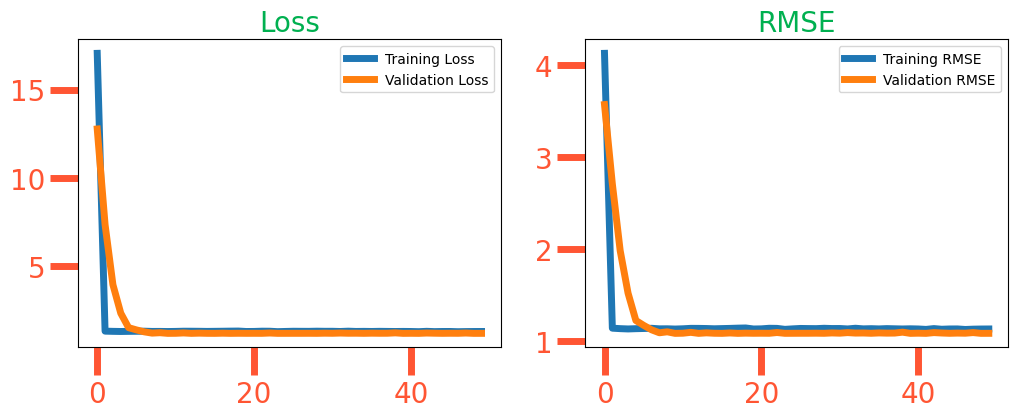

In [624]:
# ФИНАЛЬНАЯ МОДЕЛЬ С ЛУЧШИМИ ПАРАМЕТРАМИ
inputs = []
embeddings = []

# Числовые колонки
numeric_input = layers.Input(shape=(len(numeric_cols),), name='numeric')
inputs.append(numeric_input)
embeddings.append(numeric_input)

# Эмбеддинги для object колонок
for col in object_cols:
    vocab_size = X[col].nunique()
    input_layer = layers.Input(shape=(1,), name=col)
    embedding = layers.Embedding(vocab_size + 1, 8)(input_layer)
    embedding = layers.Flatten()(embedding)
    inputs.append(input_layer)
    embeddings.append(embedding)

# Объединяем с лучшими параметрами
combined = layers.Concatenate()(embeddings)
x = layers.Dense(128, activation='tanh')(combined)  #
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.2)(x)
x = layers.Dense(64, activation='tanh')(x)
x = layers.Dense(1)(x)

model = keras.Model(inputs=inputs, outputs=x)

# Компиляция и обучение с лучшими параметрами
model.compile(
    optimizer='adam',
    loss='mse',
    metrics=[keras.metrics.RootMeanSquaredError()]
)

history = model.fit(
    train_data, y_train,
    validation_data=(test_data, y_test),
    epochs=50,
    batch_size=64,
    verbose=1
)

# Финальная оценка
test_loss, test_rmse = model.evaluate(test_data, y_test, verbose=0)
print(f'ФИНАЛЬНЫЙ TEST RMSE: {test_rmse:.4f}')

# Визуализация обучения
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['root_mean_squared_error'], label='Training RMSE')
plt.plot(history.history['val_root_mean_squared_error'], label='Validation RMSE')
plt.title('RMSE')
plt.legend()
plt.show()

финальный тест рмсе составил 1.086, что вполне себе достойно, мне кажется, если еще поработать над улучшением фичей, то можно еще выиграть десятую в качестве.

**Вывод**
Подбор гиперпараметров (дропаут, батч нормализация, размер батча, вид функции активации) показал действенный способ в улучшении модели, также отмечу, что неплохой eda данных также поспособствовал хорошему предикту.

Лучшая модель соответсвует следующим параметрам:
- activation        **tanh**
- dropout            **0.2**
- batch_norm        **True**
- batch_size          **64**